In [2]:
# @title
!pip install optuna



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 14.7 MB/s eta 0:00:00


Semilla = 0
Punto inicial usado para calibrar: [-0.07486820220947266, 5.364436149597168]
corrida  1: ( -0.0749,   5.3644)
corrida  2: ( -8.2305,  -7.3594)
corrida  3: ( -3.8515,   2.6816)
corrida  4: ( -0.1981,   7.9289)
corrida  5: ( -0.8874,   2.6461)
corrida  6: ( -3.0221,  -1.9657)
corrida  7: ( -9.5535,  -6.6228)
corrida  8: ( -4.1222,   0.3704)
corrida  9: (  3.9534,   6.0002)
corrida 10: ( -6.7794,  -4.3546)


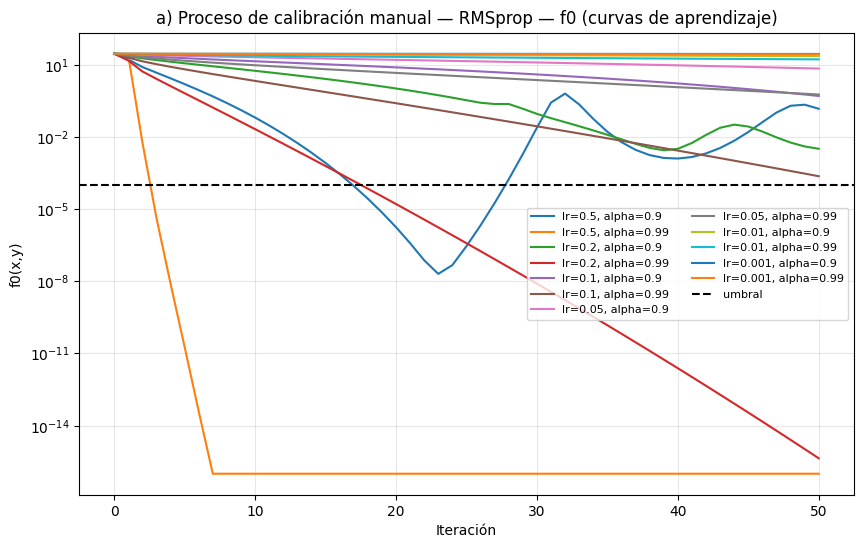

**Mejores valores (calibración manual) — RMSprop — f0:** `lr=0.5, alpha=0.99`  
Iteraciones hasta el umbral: `0` · Valor final: `3.000000e+00`


---
# 🔎 Calibración con Optuna — RMSprop — f0
## Hiperparámetros encontrados
# `lr = 0.43593  ·  alpha = 0.99521`
## Valor final de la función: `0.000000e+00`

| | Hiperparámetros | Valor final |
|---|---|---|
| **Optuna** (50 trials, TPE, seed=0) | `lr = 0.43593  ·  alpha = 0.99521` | `0.000000e+00` |
| **Manual** (grid) | `lr=0.5, alpha=0.99` | `0.000000e+00` |

---


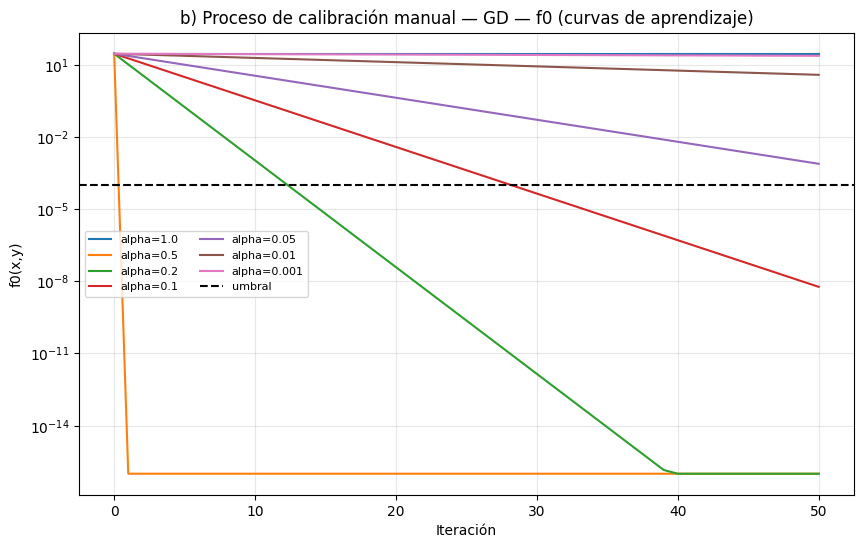

**Mejores valores (calibración manual) — GD — f0:** `alpha=0.5`  
Iteraciones hasta el umbral: `0` · Valor final: `1.000000e+00`


---
# 🔎 Calibración con Optuna — GD — f0
## Hiperparámetros encontrados
# `alpha = 0.48474`
## Valor final de la función: `0.000000e+00`

| | Hiperparámetros | Valor final |
|---|---|---|
| **Optuna** (50 trials, TPE, seed=0) | `alpha = 0.48474` | `0.000000e+00` |
| **Manual** (grid) | `alpha=0.5` | `0.000000e+00` |

---



=== d.1) f0 — GD — hiperparámetros: {'alpha': 0.4847388940154016} ===
 corrida             x0 convergió  iteraciones   f final          x final
       1  (-0.07, 5.36)        Sí            2 0.000e+00 (0.0000, 0.0000)
       2 (-8.23, -7.36)        Sí            3 0.000e+00 (0.0000, 0.0000)
       3  (-3.85, 2.68)        Sí            2 0.000e+00 (0.0000, 0.0000)
       4  (-0.20, 7.93)        Sí            2 0.000e+00 (0.0000, 0.0000)
       5  (-0.89, 2.65)        Sí            2 0.000e+00 (0.0000, 0.0000)
       6 (-3.02, -1.97)        Sí            2 0.000e+00 (0.0000, 0.0000)
       7 (-9.55, -6.62)        Sí            3 0.000e+00 (0.0000, 0.0000)
       8  (-4.12, 0.37)        Sí            2 0.000e+00 (0.0000, 0.0000)
       9   (3.95, 6.00)        Sí            2 0.000e+00 (0.0000, 0.0000)
      10 (-6.78, -4.35)        Sí            2 0.000e+00 (0.0000, 0.0000)

=== d.1) f0 — RMSprop — hiperparámetros: {'lr': 0.4359321072105287, 'alpha': 0.9952067376199338} ===
 corrida     

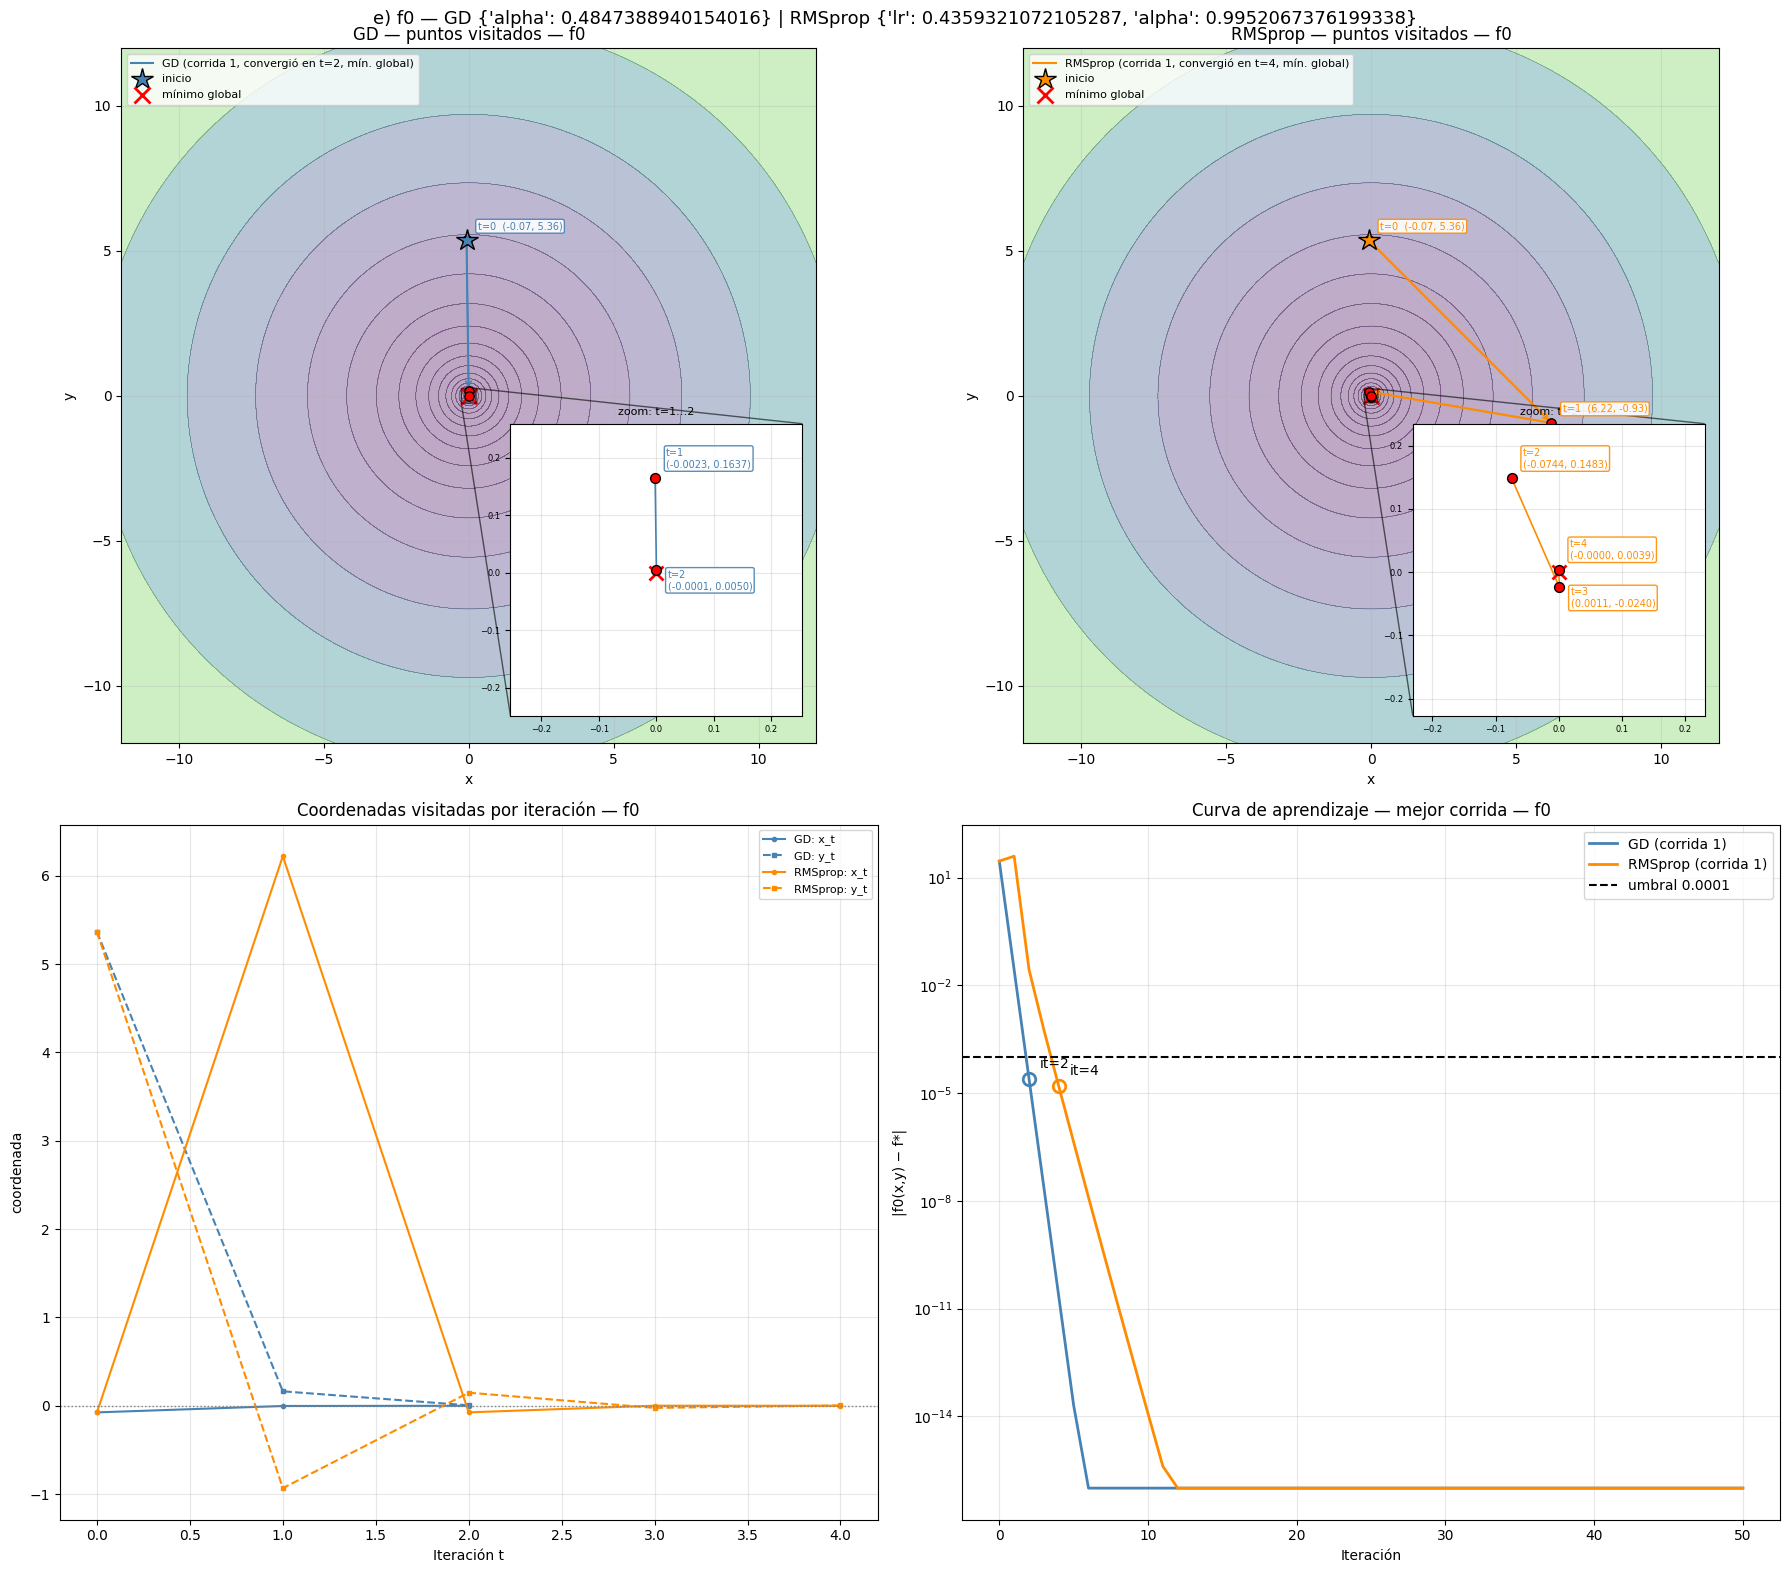

In [10]:
# @title

import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import optuna
import pandas as pd
from IPython.display import display, Markdown


optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")

N_ITER = 50
N_CORRIDAS = 10
SEMILLA = 0
UMBRAL_CONVERGENCIA = 1e-4
UMBRAL_F1 = 1e-4


def f0(punto):
    """!
    @brief Función esfera (suma de cuadrados), benchmark de optimización convexa simple.

    Tiene un único mínimo global en el origen (0,0) con valor 0. Es la función
    más simple del conjunto, útil como caso base antes de probar funciones más difíciles.

    @param punto Tensor de 2 elementos (x, y) donde se evalúa la función.
    @return Valor escalar de f0 en el punto dado (suma de los cuadrados de sus componentes).
    """
    return torch.sum(punto ** 2)


def correr_descenso_gradiente(func, x_t, alpha=0.1, n_iter=25):
    """!
    @brief Ejecuta el algoritmo de Descenso de Gradiente (GD) sobre una función objetivo.

    Utiliza autograd de PyTorch para calcular el gradiente en cada iteración
    y actualiza el punto siguiendo la dirección opuesta al gradiente.

    @param func Función objetivo a minimizar; debe aceptar un tensor de PyTorch y devolver un escalar.
    @param x_t Punto inicial (tensor de PyTorch) desde donde comienza la búsqueda.
    @param alpha Tasa de aprendizaje (learning rate) usada en cada paso.
    @param n_iter Número de iteraciones a ejecutar.
    @return Tupla (x_historial, f_historial): lista de puntos visitados y lista de valores de la función en cada punto, incluyendo el punto inicial.
    """
    x_t_normal = x_t.detach().clone().requires_grad_(True)
    x_historial_normal = [x_t_normal.detach().clone()]
    f_historial_normal = [func(x_t_normal).detach()]

    for t in range(n_iter):
        valor = func(x_t_normal)
        valor.backward()
        delta_x = x_t_normal.grad

        x_t_normal = (x_t_normal - alpha * delta_x).detach().clone().requires_grad_(True)

        f_x_t = func(x_t_normal).detach()
        x_historial_normal.append(x_t_normal.detach().clone())
        f_historial_normal.append(f_x_t)

    return x_historial_normal, f_historial_normal


def rmsprop(func, punto_inicial, lr=0.1, alpha=0.9, eps=1e-8, n_iter=25):
    """!
    @brief Ejecuta el algoritmo RMSprop sobre una función objetivo.

    RMSprop adapta la tasa de aprendizaje de forma individual para cada dimensión,
    dividiendo el gradiente por la raíz de un promedio móvil exponencial de los
    gradientes al cuadrado: v_t = alpha*v_{t-1} + (1-alpha)*g², x -= lr*g/(sqrt(v_t)+eps).

    @param func Función objetivo a minimizar.
    @param punto_inicial Punto inicial (tensor de PyTorch) desde donde comienza la búsqueda.
    @param lr Tasa de aprendizaje base.
    @param alpha Factor de decaimiento del promedio móvil de gradientes al cuadrado.
    @param eps Constante pequeña para evitar división por cero.
    @param n_iter Número de iteraciones a ejecutar.
    @return Tupla (x_t, x_historial, f_x_t_historial): punto final alcanzado, lista de puntos visitados y lista de valores de la función en cada punto.
    """
    x_t = punto_inicial.clone().requires_grad_(True)
    x_historial = [x_t.detach().clone()]
    f_x_t_historial = [func(x_t).item()]
    E_g2 = torch.zeros_like(x_t)

    for t in range(n_iter):
        if x_t.grad is not None:
            x_t.grad.zero_()

        valor = func(x_t)
        valor.backward()
        grad = x_t.grad

        with torch.no_grad():
            E_g2 = alpha * E_g2 + (1 - alpha) * grad ** 2
            x_t -= lr * grad / (torch.sqrt(E_g2) + eps)

        x_historial.append(x_t.detach().clone())
        with torch.no_grad():
            f_x_t_historial.append(func(x_t).item())

    return x_t.detach(), x_historial, f_x_t_historial


def generar_puntos_iniciales(semilla, n=N_CORRIDAS, rango=(-10, 10)):
    """!
    @brief Genera un conjunto de puntos iniciales aleatorios reproducibles.

    Usa un generador propio de PyTorch (en vez del generador global) para que
    llamadas posteriores a Optuna u otras fuentes de aleatoriedad no alteren esta secuencia.

    @param semilla Semilla para el generador aleatorio, garantiza reproducibilidad.
    @param n Cantidad de puntos iniciales a generar.
    @param rango Tupla (min, max) del rango uniforme del que se muestrean las coordenadas.
    @return Lista de n tensores de 2 elementos (x, y), cada uno un punto inicial distinto.
    """
    g = torch.Generator().manual_seed(semilla)
    return [torch.empty(2).uniform_(*rango, generator=g) for _ in range(n)]


def iteracion_convergencia(curva, umbral=UMBRAL_CONVERGENCIA):
    """!
    @brief Determina en qué iteración una curva de valores baja por debajo de un umbral.

    @param curva Lista de valores numéricos (por ejemplo, el valor de la función en cada iteración).
    @param umbral Valor límite; se considera "convergido" cuando la curva baja de este valor.
    @return Tupla (convergio, iteracion): convergio es True/False, e iteracion es el índice de la primera vez que la curva bajó del umbral (None si nunca convergió).
    """
    for i, v in enumerate(curva):
        if v < umbral:
            return True, i
    return False, None


def puntuar(curva, umbral=UMBRAL_CONVERGENCIA):
    """!
    @brief Calcula un puntaje para comparar curvas de convergencia (usado para elegir el mejor hiperparámetro).

    Prioriza primero la velocidad de convergencia (menor número de iteraciones) y,
    en caso de no converger, el valor final alcanzado. Las curvas con valores no finitos
    (NaN o infinito, señal de divergencia numérica) se descartan automáticamente.

    @param curva Lista de valores numéricos de la función a lo largo de las iteraciones.
    @param umbral Valor límite para considerar que la curva convergió.
    @return Tupla (iteraciones_hasta_umbral, valor_final); ambos "inf" si la curva diverge (contiene NaN o inf).
    """
    if not all(math.isfinite(v) for v in curva):
        return (float("inf"), float("inf"))
    convergio, it = iteracion_convergencia(curva, umbral)
    return (it if convergio else float("inf"), curva[-1])


def a_numpy(trayectoria):
    """!
    @brief Convierte una trayectoria de puntos (lista de tensores) a un arreglo NumPy.

    @param trayectoria Lista o tupla de tensores de PyTorch de forma (2,), o un único tensor de forma (T,2).
    @return Arreglo NumPy de forma (T,2) con la trayectoria completa.
    """
    if isinstance(trayectoria, (list, tuple)):
        trayectoria = torch.stack([p.detach() for p in trayectoria])
    return trayectoria.detach().cpu().numpy()


def ejecutar(metodo, func, p0, hp):
    """!
    @brief Ejecuta el método de optimización indicado (GD o RMSprop) desde un punto inicial dado.

    Función auxiliar que unifica la interfaz de ambos algoritmos, ya que
    correr_descenso_gradiente y rmsprop devuelven estructuras ligeramente distintas.

    @param metodo Cadena de texto: "GD" para Descenso de Gradiente, cualquier otro valor ejecuta RMSprop.
    @param func Función objetivo a minimizar.
    @param p0 Punto inicial (tensor de PyTorch).
    @param hp Diccionario de hiperparámetros específicos del método (alpha para GD; lr y alpha para RMSprop).
    @return Tupla (puntos, curva): lista de puntos visitados y lista de valores de la función en cada punto.
    """
    if metodo == "GD":
        puntos = list(correr_descenso_gradiente(func, p0, n_iter=N_ITER, **hp)[0])
    else:
        _, puntos, _ = rmsprop(func, p0, n_iter=N_ITER, **hp)
    with torch.no_grad():
        curva = [func(p).item() for p in puntos]
    return puntos, curva


def tabla_metodo(tabla, nombre_f, metodo):
    """!
    @brief Extrae y reformatea la sub-tabla de un método específico desde la tabla general de resultados.

    Convierte el formato de la tabla global (columnas en español con tildes, usada
    en la sección de 10 corridas) al formato esperado por graficar_e_funcion.

    @param tabla DataFrame de pandas con los resultados de todas las funciones y métodos.
    @param nombre_f Nombre de la función objetivo a filtrar (por ejemplo, "f0").
    @param metodo Nombre del método a filtrar ("GD" o "RMSprop").
    @return DataFrame de pandas con las columnas: corrida, convergio, iteracion_convergencia, valor_final, minimo.
    """
    sub = tabla[(tabla["función"] == nombre_f) & (tabla["método"] == metodo)]
    return pd.DataFrame({
        "corrida": sub["corrida"].values,
        "convergio": (sub["convergió"] == "Sí").values,
        "iteracion_convergencia": sub["iteraciones"].values,
        "valor_final": sub["f final"].values,
        "minimo": "global",
    })


def resumen_10_corridas(tabla, nombre_algoritmo):
    """!
    @brief Imprime un resumen estadístico de las 10 corridas de un algoritmo.

    Muestra cuántas corridas convergieron, el valor promedio final de la función,
    y el número promedio de iteraciones hasta convergencia (solo entre las que convergieron).

    @param tabla DataFrame de pandas generado por corridas_10 o tabla_metodo.
    @param nombre_algoritmo Nombre descriptivo del algoritmo, usado solo para el encabezado del print.
    @return No devuelve nada; imprime el resumen directamente en la salida.
    """
    valor_promedio = tabla["valor_final"].mean()
    its = [it for it, c in zip(tabla["iteracion_convergencia"], tabla["convergio"]) if c]
    iter_promedio = sum(its) / len(its) if its else None
    print(f"--- Resumen {nombre_algoritmo} ---")
    print(f"Corridas que convergieron: {tabla['convergio'].sum()}/{N_CORRIDAS}")
    print(f"Valor promedio de la función: {valor_promedio:.8e}")
    print(f"Iteración promedio de convergencia (solo convergidas): {iter_promedio}\n")


def encontrar_mejor_corrida(tabla, puntos_iniciales):
    """!
    @brief Identifica y reporta la mejor corrida de un conjunto de 10 (la de convergencia más rápida).

    Si ninguna corrida convergió, reporta la de mejor esfuerzo (menor valor final alcanzado).

    @param tabla DataFrame de pandas con los resultados de las 10 corridas.
    @param puntos_iniciales Lista de los puntos iniciales usados, en el mismo orden que las filas de la tabla.
    @return El punto inicial (tensor de PyTorch) correspondiente a la mejor corrida encontrada.
    """
    convergidas = tabla[tabla["convergio"] == True]
    if len(convergidas) > 0:
        idx = convergidas["iteracion_convergencia"].idxmin()
        fila = tabla.loc[idx]
        print(f"Mejor corrida: #{fila['corrida']}, convergió en iteración {fila['iteracion_convergencia']}")
    else:
        idx = tabla["valor_final"].idxmin()
        fila = tabla.loc[idx]
        print(f"Ninguna corrida convergió. Mejor esfuerzo: corrida #{fila['corrida']}, "
              f"valor final = {fila['valor_final']:.6f}")
    print(f"Punto inicial: {puntos_iniciales[idx]}")
    return puntos_iniciales[idx]


def graficar_calibracion(resultados, titulo, ylabel, umbral, fmt_label):
    """!
    @brief Grafica las curvas de aprendizaje de una malla (grid) de hiperparámetros durante la calibración manual.

    @param resultados Diccionario donde cada clave es una combinación de hiperparámetros y cada valor es la curva (lista de valores de la función por iteración).
    @param titulo Título del gráfico.
    @param ylabel Etiqueta del eje Y.
    @param umbral Valor de umbral de convergencia, se dibuja como línea horizontal punteada de referencia.
    @param fmt_label Función que recibe la clave del diccionario y devuelve el texto de la leyenda para esa curva.
    @return No devuelve nada; muestra el gráfico directamente con plt.show().
    """
    plt.figure(figsize=(10, 6))
    for k, curva in resultados.items():
        plt.plot([max(v, 1e-16) for v in curva], label=fmt_label(k))
    plt.axhline(umbral, ls="--", color="k", label="umbral")
    plt.xlabel("Iteración"); plt.ylabel(ylabel); plt.yscale("log")
    plt.title(titulo); plt.legend(fontsize=8, ncol=2); plt.grid(True, alpha=0.3)
    plt.show()


def graficar_manual_vs_optuna(curva_optuna, curva_manual, lab_optuna, lab_manual, titulo, ylabel, umbral):
    """!
    @brief Grafica lado a lado la curva de convergencia encontrada por Optuna versus la calibración manual.

    @param curva_optuna Lista de valores de la función por iteración, usando los hiperparámetros de Optuna.
    @param curva_manual Lista de valores de la función por iteración, usando los hiperparámetros manuales.
    @param lab_optuna Etiqueta de leyenda para la curva de Optuna.
    @param lab_manual Etiqueta de leyenda para la curva manual.
    @param titulo Título del gráfico.
    @param ylabel Etiqueta del eje Y.
    @param umbral Valor de umbral de convergencia, se dibuja como línea horizontal punteada de referencia.
    @return No devuelve nada; muestra el gráfico directamente con plt.show().
    """
    plt.figure(figsize=(10, 6))
    plt.plot([max(v, 1e-16) for v in curva_optuna], color="darkorange", lw=2, label=lab_optuna)
    plt.plot([max(v, 1e-16) for v in curva_manual], "--", color="steelblue", label=lab_manual)
    plt.axhline(umbral, ls="--", color="k", label="umbral")
    plt.yscale("log"); plt.xlabel("Iteración"); plt.ylabel(ylabel)
    plt.title(titulo); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()


def graficar_curvas_nivel_trayectoria(func, trayectoria, titulo, rango=(-10, 10), n_puntos=300):
    """!
    @brief Grafica las curvas de nivel de una función junto con la trayectoria seguida por un optimizador.

    Evalúa la función sobre una malla 2D dentro del rango dado y superpone la
    trayectoria de puntos visitados, marcando el punto inicial y el final.

    @param func Función objetivo a graficar.
    @param trayectoria Lista de puntos (tensores) visitados durante la optimización.
    @param titulo Título del gráfico.
    @param rango Tupla (min, max) del rango de x e y a graficar.
    @param n_puntos Resolución de la malla (cantidad de puntos por eje).
    @return No devuelve nada; muestra el gráfico directamente con plt.show().
    """
    x = np.linspace(rango[0], rango[1], n_puntos)
    X, Y = np.meshgrid(x, x)
    Z = np.zeros_like(X)
    with torch.no_grad():
        for i in range(n_puntos):
            for j in range(n_puntos):
                Z[i, j] = func(torch.tensor([X[i, j], Y[i, j]], dtype=torch.float32)).item()

    plt.figure(figsize=(8, 7))
    cont = plt.contour(X, Y, Z, levels=30, cmap="viridis")
    plt.colorbar(cont, label="f(x,y)")
    T = a_numpy(trayectoria)
    plt.plot(T[:, 0], T[:, 1], 'o-', color="red", markersize=4, linewidth=1.5, label="Trayectoria")
    plt.plot(T[0, 0], T[0, 1], 'o', color="black", markersize=10, label="Punto inicial")
    plt.plot(T[-1, 0], T[-1, 1], '*', color="gold", markersize=15, label="Punto final")
    plt.xlabel("x"); plt.ylabel("y"); plt.title(titulo); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()


def graficar_curva_aprendizaje(func, historial, titulo):
    """!
    @brief Grafica la curva de aprendizaje (valor de la función vs iteración) en escala logarítmica.

    @param func Función objetivo usada para evaluar cada punto del historial.
    @param historial Lista de puntos (tensores) visitados durante la optimización.
    @param titulo Título del gráfico.
    @return No devuelve nada; muestra el gráfico directamente con plt.show().
    """
    with torch.no_grad():
        curva = [func(p).item() for p in historial]
    plt.figure(figsize=(8, 5))
    plt.plot(curva, color="steelblue", linewidth=2)
    plt.xlabel("Iteración"); plt.ylabel("f(x,y)"); plt.yscale("log")
    plt.title(titulo); plt.grid(True, alpha=0.3)
    plt.show()


def malla_f(func, lim, n=200):
    """!
    @brief Evalúa una función sobre una malla cuadrada 2D, usada para graficar curvas de nivel.

    Intenta usar torch.vmap para vectorizar la evaluación (más rápido); si la función
    no es compatible con vmap, recurre a un bucle simple como respaldo.

    @param func Función objetivo a evaluar, debe aceptar un tensor de 2 elementos.
    @param lim Límite absoluto del rango a evaluar: la malla cubre [-lim, lim] en ambos ejes.
    @param n Resolución de la malla (cantidad de puntos por eje).
    @return Tupla (X, Y, Z): mallas de coordenadas X e Y (NumPy), y Z con los valores de la función evaluada en cada punto.
    """
    xs = np.linspace(-lim, lim, n)
    X, Y = np.meshgrid(xs, xs)
    pts = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        try:
            Z = torch.vmap(func)(pts)
        except Exception:
            Z = torch.stack([func(p) for p in pts])
    return X, Y, Z.reshape(n, n).numpy()


def dibujar_panel(ax, X, Y, Z, niveles, P, ult, color, etiqueta, x_opt, cada=None):
    """!
    @brief Dibuja un panel de contorno con la trayectoria de un optimizador, incluyendo zoom sobre el punto final.

    Dibuja las curvas de nivel de la función, la trayectoria completa con flechas de dirección,
    marca el/los óptimo(s) global(es) conocido(s), clasifica el punto final como "global" o
    "local" según su distancia al óptimo más cercano, y agrega un recuadro de zoom sobre las
    últimas iteraciones para apreciar el detalle de la convergencia final.

    @param ax Eje de matplotlib (subplot) donde se dibuja el panel.
    @param X Malla de coordenadas X (NumPy), generada por malla_f.
    @param Y Malla de coordenadas Y (NumPy), generada por malla_f.
    @param Z Malla de valores de la función (NumPy), generada por malla_f.
    @param niveles Niveles de contorno a dibujar (lista o arreglo de valores).
    @param P Arreglo NumPy (T,2) con la trayectoria completa de puntos visitados.
    @param ult Índice de la última iteración a graficar (por ejemplo, la iteración de convergencia).
    @param color Color usado para dibujar la trayectoria de este método.
    @param etiqueta Texto de leyenda para la trayectoria.
    @param x_opt Óptimo(s) global(es) conocido(s): una tupla (x,y) única, o una lista de tuplas si hay varios mínimos globales.
    @param cada Cada cuántas iteraciones colocar una etiqueta de texto con las coordenadas (None = automático).
    @return No devuelve nada; dibuja directamente sobre el eje `ax` recibido.
    """
    if isinstance(x_opt[0], (list, tuple, np.ndarray)):
        optimos = [np.array(o, dtype=float) for o in x_opt]
    else:
        optimos = [np.array(x_opt, dtype=float)]

    ax.contourf(X, Y, Z, levels=niveles, cmap="viridis", alpha=0.35)
    ax.contour(X, Y, Z, levels=niveles, colors="k", linewidths=0.3, alpha=0.4)
    ax.plot(P[:ult+1, 0], P[:ult+1, 1], "-", color=color, lw=1.5, label=etiqueta)
    ax.scatter(P[:ult+1, 0], P[:ult+1, 1], s=45, color="red", edgecolor="k", zorder=5)
    for t in range(ult):
        ax.annotate("", xy=P[t+1], xytext=P[t],
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.1), zorder=4)
    ax.plot(P[0, 0], P[0, 1], "*", ms=16, color=color, mec="k", zorder=7, label="inicio")

    for i, opt in enumerate(optimos):
        ax.plot(*opt, "rx", ms=12, mew=2, label="mínimo global" if i == 0 else None)

    centro = P[ult]
    dist_optimos = [np.linalg.norm(centro - opt) for opt in optimos]
    dist_min = min(dist_optimos)
    x_opt_cercano = optimos[int(np.argmin(dist_optimos))]

    if dist_min > 0.5:
        loc = np.round(centro)
        ax.plot(*loc, "^", ms=11, color="magenta", mec="k", zorder=7,
                label=f"mín. local ≈ ({loc[0]:.0f}, {loc[1]:.0f})")

    d = np.linalg.norm(P[:ult+1] - centro, axis=1)
    lejos = [t for t in range(ult+1) if d[t] >= 0.1 * max(d[0], 1e-12)]
    s = min((max(lejos) + 1) if lejos else 1, ult)

    if cada is None:
        cada = max(1, math.ceil(s / 12))
    for t in range(0, s, cada):
        ax.annotate(f"t={t}  ({P[t,0]:.2f}, {P[t,1]:.2f})", xy=P[t], xytext=(8, 8),
                    textcoords="offset points", fontsize=7, color=color, zorder=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.9))

    if s <= ult:
        pz = P[s:ult+1]
        r = max(np.abs(pz - centro).max() * 1.6, 1e-3)
        axins = ax.inset_axes([0.56, 0.04, 0.42, 0.42])
        axins.plot(pz[:, 0], pz[:, 1], "-", color=color, lw=1.2)
        axins.scatter(pz[:, 0], pz[:, 1], s=50, color="red", edgecolor="k", zorder=5)
        if dist_min <= r:
            axins.plot(*x_opt_cercano, "rx", ms=10, mew=2)
        idxs = list(range(s, ult+1, max(1, math.ceil((ult - s + 1) / 10))))
        if ult not in idxs:
            idxs.append(ult)
        for k, t in enumerate(idxs):
            dx, dy = (8, 8) if k % 2 == 0 else (8, -14)
            axins.annotate(f"t={t}\n({P[t,0]:.4f}, {P[t,1]:.4f})", xy=P[t], xytext=(dx, dy),
                           textcoords="offset points", fontsize=7, color=color,
                           bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.9))
        axins.set_xlim(centro[0]-r, centro[0]+r); axins.set_ylim(centro[1]-r, centro[1]+r)
        axins.set_title(f"zoom: t={s}…{ult}", fontsize=8)
        axins.tick_params(labelsize=6); axins.grid(True, alpha=0.3)
        ax.indicate_inset_zoom(axins, edgecolor="k", alpha=0.6)

    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
    ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)


def graficar_e_funcion(nombre_f, func, tablas, ejecutores, hp, x_opt=(0.0, 0.0), f_opt=0.0,
                       umbral=UMBRAL_CONVERGENCIA, n_malla=200, niveles_log=True):
    """!
    @brief Genera el reporte visual completo (inciso e) de la mejor corrida de cada método.

    Produce una figura con 4 paneles: (1) contorno + trayectoria de GD, (2) contorno + trayectoria
    de RMSprop, (3) coordenadas x,y visitadas por iteración de ambos métodos, y (4) curva de
    aprendizaje (error respecto al óptimo) en escala logarítmica. También imprime, por consola,
    la tabla de puntos visitados en cada iteración de la mejor corrida de cada método.

    @param nombre_f Nombre descriptivo de la función objetivo (usado en títulos).
    @param func Función objetivo a graficar.
    @param tablas Diccionario {"GD": DataFrame, "RMSprop": DataFrame} con los resultados de las 10 corridas de cada método.
    @param ejecutores Diccionario {"GD": función, "RMSprop": función} donde cada función recibe un punto inicial y devuelve la trayectoria completa.
    @param hp Diccionario {"GD": dict, "RMSprop": dict} con los hiperparámetros usados por cada método (para mostrar en el título).
    @param x_opt Óptimo(s) global(es) conocido(s): una tupla (x,y) única, o una lista de tuplas si la función tiene varios mínimos globales.
    @param f_opt Valor de la función en el óptimo global (normalmente 0.0).
    @param umbral Valor de umbral de convergencia, usado para la línea de referencia en la curva de aprendizaje.
    @param n_malla Resolución de la malla usada para dibujar las curvas de nivel.
    @param niveles_log Si es True, usa niveles de contorno en escala logarítmica (útil para funciones con rango de valores muy amplio).
    @return No devuelve nada; muestra la figura directamente con plt.show() e imprime las tablas de puntos visitados por consola.
    """
    lim = max(p.abs().max().item() for p in puntos_iniciales) * 1.15 + 1
    X, Y, Z = malla_f(func, lim, n=n_malla)
    if niveles_log:
        Zplot = np.clip(Z - f_opt, 1e-3, None)
        niveles = np.logspace(np.log10(Zplot.min()), np.log10(Zplot.max()), 20)
    else:
        Zplot = Z
        niveles = np.linspace(Z.min(), Z.max(), 25)

    fig, axs = plt.subplots(2, 2, figsize=(18, 16))
    (ax_gd, ax_rms), (ax_xy, ax_curva) = axs
    colores = {"GD": "steelblue", "RMSprop": "darkorange"}
    paneles = {"GD": ax_gd, "RMSprop": ax_rms}

    for metodo in ["GD", "RMSprop"]:
        sub = tablas[metodo]
        conv = sub[sub["convergio"] == True]
        if len(conv):
            fila = conv.loc[conv["iteracion_convergencia"].astype(int).idxmin()]
            ult = int(fila["iteracion_convergencia"]); estado = f"convergió en t={ult}"
        else:
            fila = sub.loc[sub["valor_final"].idxmin()]
            ult = None; estado = "no convergió (mejor esfuerzo)"
        idx = int(fila["corrida"]) - 1

        puntos = ejecutores[metodo](puntos_iniciales[idx])
        P = a_numpy(puntos)
        with torch.no_grad():
            curva = [func(p).item() for p in puntos]
        if ult is None:
            ult = len(P) - 1
        etiqueta = f"{metodo} (corrida {idx+1}, {estado}, mín. {fila.get('minimo', '?')})"

        dibujar_panel(paneles[metodo], X, Y, Zplot, niveles, P, ult, colores[metodo], etiqueta, x_opt)
        paneles[metodo].set_title(f"{metodo} — puntos visitados — {nombre_f}")

        ts = np.arange(ult + 1)
        ax_xy.plot(ts, P[:ult+1, 0], "-o", ms=3, color=colores[metodo], label=f"{metodo}: x_t")
        ax_xy.plot(ts, P[:ult+1, 1], "--s", ms=3, color=colores[metodo], label=f"{metodo}: y_t")

        error = [max(abs(v - f_opt), 1e-16) for v in curva]
        ax_curva.plot(error, lw=2, color=colores[metodo], label=f"{metodo} (corrida {idx+1})")
        if fila["convergio"] == True:
            ax_curva.plot(ult, error[ult], "o", ms=9, mfc="none", mew=2, color=colores[metodo])
            ax_curva.annotate(f"it={ult}", (ult, error[ult]), textcoords="offset points", xytext=(8, 8))

        print(f"\n--- {nombre_f} — {metodo} — corrida {idx+1} — puntos visitados ---")
        print(f"{'t':>3} {'x':>12} {'y':>12} {'f(x,y)':>14}")
        for t in range(ult + 1):
            print(f"{t:>3} {P[t,0]:>12.6f} {P[t,1]:>12.6f} {curva[t]:>14.6e}")

    if not isinstance(x_opt[0], (list, tuple, np.ndarray)):
      ax_xy.axhline(x_opt[0], color="gray", ls=":", lw=1)
    ax_xy.set_xlabel("Iteración t"); ax_xy.set_ylabel("coordenada")
    ax_xy.set_title(f"Coordenadas visitadas por iteración — {nombre_f}")
    ax_xy.legend(fontsize=8); ax_xy.grid(True, alpha=0.3)

    ax_curva.axhline(umbral, ls="--", color="k", label=f"umbral {umbral:g}")
    ax_curva.set_yscale("log")
    ax_curva.set_xlabel("Iteración"); ax_curva.set_ylabel(f"|{nombre_f}(x,y) − f*|")
    ax_curva.set_title(f"Curva de aprendizaje — mejor corrida — {nombre_f}")
    ax_curva.legend(); ax_curva.grid(True, alpha=0.3)

    fig.suptitle(f"e) {nombre_f} — GD {hp['GD']} | RMSprop {hp['RMSprop']}", fontsize=13)
    plt.tight_layout(); plt.show()


def reportar_mejor_manual(metodo, nombre_f, hp, valor_final, it=None):
    """!
    @brief Imprime en formato Markdown un resumen de los mejores hiperparámetros encontrados manualmente.

    @param metodo Nombre del algoritmo ("GD" o "RMSprop").
    @param nombre_f Nombre de la función objetivo calibrada.
    @param hp Diccionario con los hiperparámetros seleccionados como los mejores.
    @param valor_final Valor final de la función alcanzado con estos hiperparámetros.
    @param it Número de iteraciones hasta alcanzar el umbral de convergencia. Opcional; si no se reporta, se omite esa línea.
    @return No devuelve nada; muestra el resumen directamente con display(Markdown(...)).
    """
    hp_txt = ", ".join(f"{k}={v}" for k, v in hp.items())
    display(Markdown(
        f"**Mejores valores (calibración manual) — {metodo} — {nombre_f}:** `{hp_txt}`  \n"
        + (f"Iteraciones hasta el umbral: `{int(it) if it != float('inf') else 'no alcanzó el umbral'}` · "
           if it is not None else "")
        + f"Valor final: `{valor_final:.6e}`"))


def reportar_optuna(metodo, nombre_f, study, hp_manual, valor_manual):
    """!
    @brief Imprime en formato Markdown un reporte comparativo entre los hiperparámetros de Optuna y los manuales.

    @param metodo Nombre del algoritmo ("GD" o "RMSprop").
    @param nombre_f Nombre de la función objetivo calibrada.
    @param study Objeto de estudio de Optuna ya optimizado, contiene los mejores hiperparámetros encontrados.
    @param hp_manual Diccionario con los hiperparámetros elegidos manualmente, para comparación.
    @param valor_manual Valor final de la función alcanzado con los hiperparámetros manuales.
    @return No devuelve nada; muestra el reporte directamente con display(Markdown(...)).
    """
    params_md = "  ·  ".join(f"{k} = {v:.5f}" for k, v in study.best_params.items())
    manual_md = ", ".join(f"{k}={v}" for k, v in hp_manual.items())
    valor_opt = study.best_trial.user_attrs.get("valor_final", study.best_value)
    display(Markdown(f"""
---
# 🔎 Calibración con Optuna — {metodo} — {nombre_f}
## Hiperparámetros encontrados
# `{params_md}`
## Valor final de la función: `{valor_opt:.6e}`

| | Hiperparámetros | Valor final |
|---|---|---|
| **Optuna** ({len(study.trials)} trials, TPE, seed=0) | `{params_md}` | `{valor_opt:.6e}` |
| **Manual** (grid) | `{manual_md}` | `{valor_manual:.6e}` |

---
"""))

puntos_iniciales = generar_puntos_iniciales(SEMILLA)
punto_inicial = puntos_iniciales[0]      # punto usado para calibrar

print(f"Semilla = {SEMILLA}")
print("Punto inicial usado para calibrar:", punto_inicial.tolist())
for i, p in enumerate(puntos_iniciales):
    print(f"corrida {i+1:>2}: ({p[0]:8.4f}, {p[1]:8.4f})")



#  a) CALIBRACIÓN MANUAL — RMSprop — f0

lrs_rms = [0.5, 0.2, 0.1, 0.05, 0.01, 0.001]
alphas_rms = [0.9, 0.99]

resultados_rms_calib = {}
for lr in lrs_rms:
    for alpha in alphas_rms:
        _, _, curva = rmsprop(f0, punto_inicial, lr=lr, alpha=alpha, n_iter=N_ITER)
        resultados_rms_calib[(lr, alpha)] = curva

graficar_calibracion(resultados_rms_calib,
                     "a) Proceso de calibración manual — RMSprop — f0 (curvas de aprendizaje)",
                     "f0(x,y)", UMBRAL_CONVERGENCIA,
                     fmt_label=lambda k: f"lr={k[0]}, alpha={k[1]}")

# Reporte de mejores valores
mejor_combo_rms = min(resultados_rms_calib, key=lambda k: puntuar(resultados_rms_calib[k]))
mejor_lr_rms, mejor_alpha_rms = mejor_combo_rms
it_mejor_rms = puntuar(resultados_rms_calib[mejor_combo_rms])[0]
valor_manual_rms = resultados_rms_calib[mejor_combo_rms][-1]
reportar_mejor_manual("RMSprop", "f0", dict(lr=mejor_lr_rms, alpha=mejor_alpha_rms),
                      it_mejor_rms, valor_manual_rms)


# . a.1) CALIBRACIÓN CON OPTUNA — RMSprop — f0  (solo reporte)
def objetivo_rms_f0(trial):
    """!
    @brief Función objetivo de Optuna para calibrar RMSprop sobre f0.

    Corre RMSprop con los hiperparámetros propuestos por Optuna y calcula un
    puntaje que premia la convergencia temprana bajo el umbral, y penaliza
    fuertemente (1e6) cualquier corrida que diverja (produzca NaN o infinito).

    @param trial Objeto Trial de Optuna, usado para muestrear los hiperparámetros lr y alpha.
    @return Puntaje escalar a minimizar: menor es mejor (iteración de convergencia si convergió, o una penalización creciente según qué tan lejos quedó del umbral si no convergió).
    """
    lr = trial.suggest_float("lr", 1e-4, 1.0, log=True)
    alpha = trial.suggest_float("alpha", 0.8, 0.999)
    _, _, curva = rmsprop(f0, punto_inicial, lr=lr, alpha=alpha, n_iter=N_ITER)
    trial.set_user_attr("valor_final", curva[-1])
    if not all(math.isfinite(v) for v in curva):
        return 1e6
    convergio, it = iteracion_convergencia(curva, UMBRAL_CONVERGENCIA)     # mismo criterio que el manual
    if convergio:
        return it + curva[it] / UMBRAL_CONVERGENCIA
    return N_ITER + max(math.log10(curva[-1]) - math.log10(UMBRAL_CONVERGENCIA), 0.0)

study_rms_f0 = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=0))
study_rms_f0.optimize(objetivo_rms_f0, n_trials=50)

mejor_lr_rms_optuna = study_rms_f0.best_params["lr"]
mejor_alpha_rms_optuna = study_rms_f0.best_params["alpha"]
reportar_optuna("RMSprop", "f0", study_rms_f0,
                hp_manual=dict(lr=mejor_lr_rms, alpha=mejor_alpha_rms), valor_manual=valor_manual_rms)



# ============================================================
# 8. b) LO ANTERIOR PARA DESCENSO DE GRADIENTE — f0
# ============================================================

alphas_gd = [1.0, 0.5, 0.2, 0.1, 0.05, 0.01, 0.001]

resultados_gd_calib = {}
for alpha in alphas_gd:
    historial, _ = correr_descenso_gradiente(f0, punto_inicial, alpha=alpha, n_iter=N_ITER)
    with torch.no_grad():
        resultados_gd_calib[alpha] = [f0(p).item() for p in historial]

graficar_calibracion(resultados_gd_calib,
                     "b) Proceso de calibración manual — GD — f0 (curvas de aprendizaje)",
                     "f0(x,y)", UMBRAL_CONVERGENCIA,
                     fmt_label=lambda k: f"alpha={k}")

mejor_alpha_gd = min(resultados_gd_calib, key=lambda k: puntuar(resultados_gd_calib[k]))
it_mejor_gd = puntuar(resultados_gd_calib[mejor_alpha_gd])[0]
valor_manual_gd = resultados_gd_calib[mejor_alpha_gd][-1]
reportar_mejor_manual("GD", "f0", dict(alpha=mejor_alpha_gd), it_mejor_gd, valor_manual_gd)

# --- b.1) Optuna GD: solo reporte ---
def objetivo_gd_f0(trial):
    """!
    @brief Función objetivo de Optuna para calibrar Descenso de Gradiente sobre f0.

    Corre GD con el alpha (learning rate) propuesto por Optuna y calcula un
    puntaje que premia la convergencia temprana bajo el umbral, y penaliza
    fuertemente (1e6) cualquier corrida que diverja (produzca NaN o infinito).

    @param trial Objeto Trial de Optuna, usado para muestrear el hiperparámetro alpha.
    @return Puntaje escalar a minimizar: menor es mejor (iteración de convergencia si convergió, o una penalización creciente según qué tan lejos quedó del umbral si no convergió).
    """
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    historial, _ = correr_descenso_gradiente(f0, punto_inicial, alpha=alpha, n_iter=N_ITER)
    with torch.no_grad():
        curva = [f0(p).item() for p in historial]
    trial.set_user_attr("valor_final", curva[-1])
    if not all(math.isfinite(v) for v in curva):
        return 1e6
    convergio, it = iteracion_convergencia(curva, UMBRAL_CONVERGENCIA)
    if convergio:
        return it + curva[it] / UMBRAL_CONVERGENCIA
    return N_ITER + max(math.log10(curva[-1]) - math.log10(UMBRAL_CONVERGENCIA), 0.0)

study_gd_f0 = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=0))
study_gd_f0.optimize(objetivo_gd_f0, n_trials=50)

mejor_alpha_gd_optuna = study_gd_f0.best_params["alpha"]
reportar_optuna("GD", "f0", study_gd_f0,
                hp_manual=dict(alpha=mejor_alpha_gd), valor_manual=valor_manual_gd)

# 9. d) 10 CORRIDAS con los mejores valores — máx. 50 iteraciones — f0

configs = {
    "f0": {
        "func": f0,
        "GD":      dict(alpha=mejor_alpha_gd_optuna),
        "RMSprop": dict(lr=mejor_lr_rms_optuna, alpha=mejor_alpha_rms_optuna),
        "f_opt": 0.0,
        "x_opt": (0.0, 0.0),
    },
}

filas, corridas = [], {}
for nombre_f, cfg in configs.items():
    for metodo in ["GD", "RMSprop"]:
        for i, p0 in enumerate(puntos_iniciales):
            puntos, curva = ejecutar(metodo, cfg["func"], p0, cfg[metodo])
            corridas[(nombre_f, metodo, i)] = (puntos, curva)
            error = [abs(v - cfg["f_opt"]) for v in curva]
            divergio = not all(math.isfinite(v) for v in curva)
            convergio, it = (False, None) if divergio else iteracion_convergencia(error, UMBRAL_CONVERGENCIA)
            filas.append({
                "función": nombre_f, "método": metodo, "corrida": i + 1,
                "x0": f"({p0[0]:.2f}, {p0[1]:.2f})",
                "convergió": "Sí" if convergio else ("Divergió" if divergio else "No"),
                "iteraciones": it if convergio else np.nan,
                "f final": curva[-1],
                "x final": f"({puntos[-1][0]:.4f}, {puntos[-1][1]:.4f})",
            })

tabla = pd.DataFrame(filas)

# d.1) tabla por método
for (nombre_f, metodo), sub in tabla.groupby(["función", "método"]):
    print(f"\n=== d.1) {nombre_f} — {metodo} — hiperparámetros: {configs[nombre_f][metodo]} ===")
    print(sub.drop(columns=["función", "método"]).to_string(index=False))

# d.2) promedios
resumen = (tabla.groupby(["función", "método"])
           .agg(corridas_convergidas=("convergió", lambda s: int((s == "Sí").sum())),
                f_promedio=("f final", "mean"),
                iteraciones_promedio=("iteraciones", "mean"))
           .reset_index())
resumen["corridas_convergidas"] = resumen["corridas_convergidas"].astype(str) + f"/{N_CORRIDAS}"
print("\n=== d.2) Valor promedio de f e iteraciones promedio (10 corridas) ===")
print(resumen.to_string(index=False))


#  e) MEJOR CORRIDA (convergencia más rápida) — curvas de nivel + curva de aprendizaje — f0

cfg0 = configs["f0"]
graficar_e_funcion(
    "f0", f0,
    tablas={"GD": tabla_metodo(tabla, "f0", "GD"),
            "RMSprop": tabla_metodo(tabla, "f0", "RMSprop")},
    ejecutores={
        "GD":      lambda p0: correr_descenso_gradiente(f0, p0, n_iter=N_ITER, **cfg0["GD"])[0],
        "RMSprop": lambda p0: rmsprop(f0, p0, n_iter=N_ITER, **cfg0["RMSprop"])[1],
    },
    hp={"GD": cfg0["GD"], "RMSprop": cfg0["RMSprop"]},
    x_opt=cfg0["x_opt"], f_opt=cfg0["f_opt"],
    umbral=UMBRAL_CONVERGENCIA, n_malla=200, niveles_log=True,
)



Punto inicial usado para calibrar (f1): [-0.07486820220947266, 5.364436149597168]


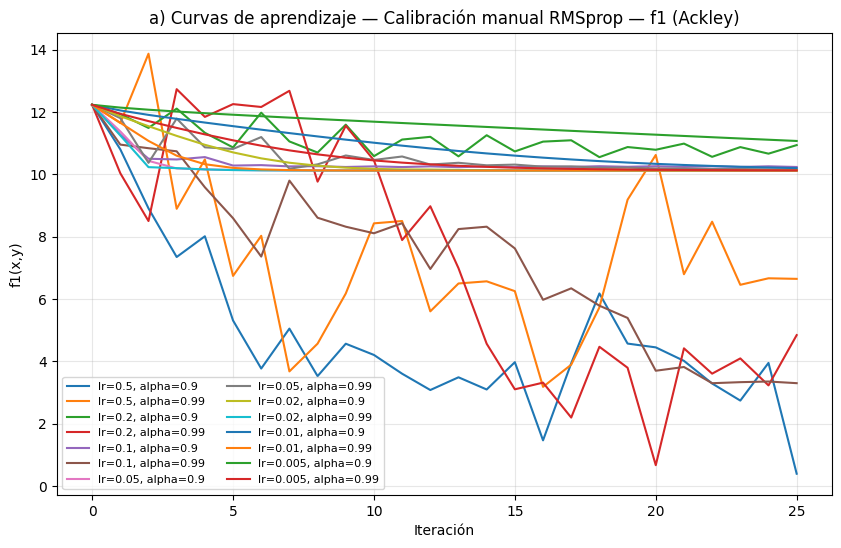

**Mejores valores (calibración manual) — RMSprop — f1:** `lr=0.5, alpha=0.9`  
Valor final: `3.995018e-01`


---
# 🔎 Optuna — RMSprop — f1

## Hiperparámetros encontrados
# `lr = 0.44898  ·  alpha = 0.81576`

## Valor final de la función: `1.287655e+00`

| | Hiperparámetros | Valor final |
|---|---|---|
| **Optuna** (50 trials, TPE, seed=0) | `lr = 0.44898  ·  alpha = 0.81576` | `1.287655e+00` |
| **Manual** (grid) | `lr=0.5, alpha=0.9` | `3.995018e-01` |

**Optuna no supera al manual** (diferencia = -8.882e-01)

---


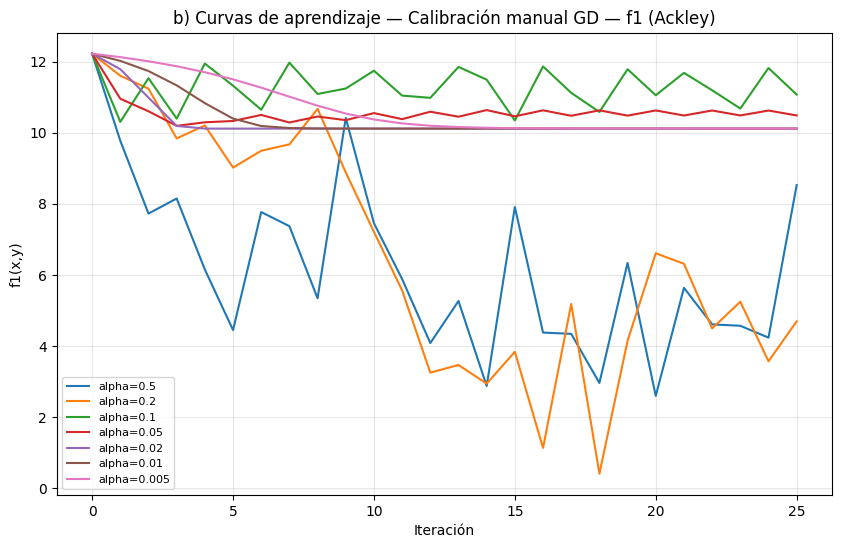

**Mejores valores (calibración manual) — GD — f1:** `alpha=0.2`  
Valor final: `4.692575e+00`


---
# 🔎 Optuna — GD — f1

## Hiperparámetros encontrados
# `alpha = 0.13093`

## Valor final de la función: `1.846687e+00`

| | Hiperparámetros | Valor final |
|---|---|---|
| **Optuna** (25 trials, TPE, seed=0) | `alpha = 0.13093` | `1.846687e+00` |
| **Manual** (grid) | `alpha=0.2` | `4.692575e+00` |

**Optuna mejora al manual** (diferencia = +2.846e+00)

---


=== d.1) Tabla Descenso de Gradiente (Optuna) — 10 corridas ===
 corrida    punto_inicial  convergio iteracion_convergencia  valor_final minimo
       1  [-0.075, 5.364]      False           No convergió    3.770e+00  local
       2  [-8.23, -7.359]      False           No convergió    1.473e+01  local
       3  [-3.852, 2.682]      False           No convergió    4.420e+00  local
       4  [-0.198, 7.929]      False           No convergió    1.192e+01  local
       5  [-0.887, 2.646]      False           No convergió    3.236e+00  local
       6 [-3.022, -1.966]      False           No convergió    2.838e+00 global
       7 [-9.553, -6.623]      False           No convergió    1.497e+01  local
       8   [-4.122, 0.37]      False           No convergió    4.381e+00  local
       9     [3.953, 6.0]      False           No convergió    2.145e+00 global
      10 [-6.779, -4.355]      False           No convergió    1.035e+01  local 

=== d.1) Tabla RMSprop (Optuna) — 10 corridas ===
 cor

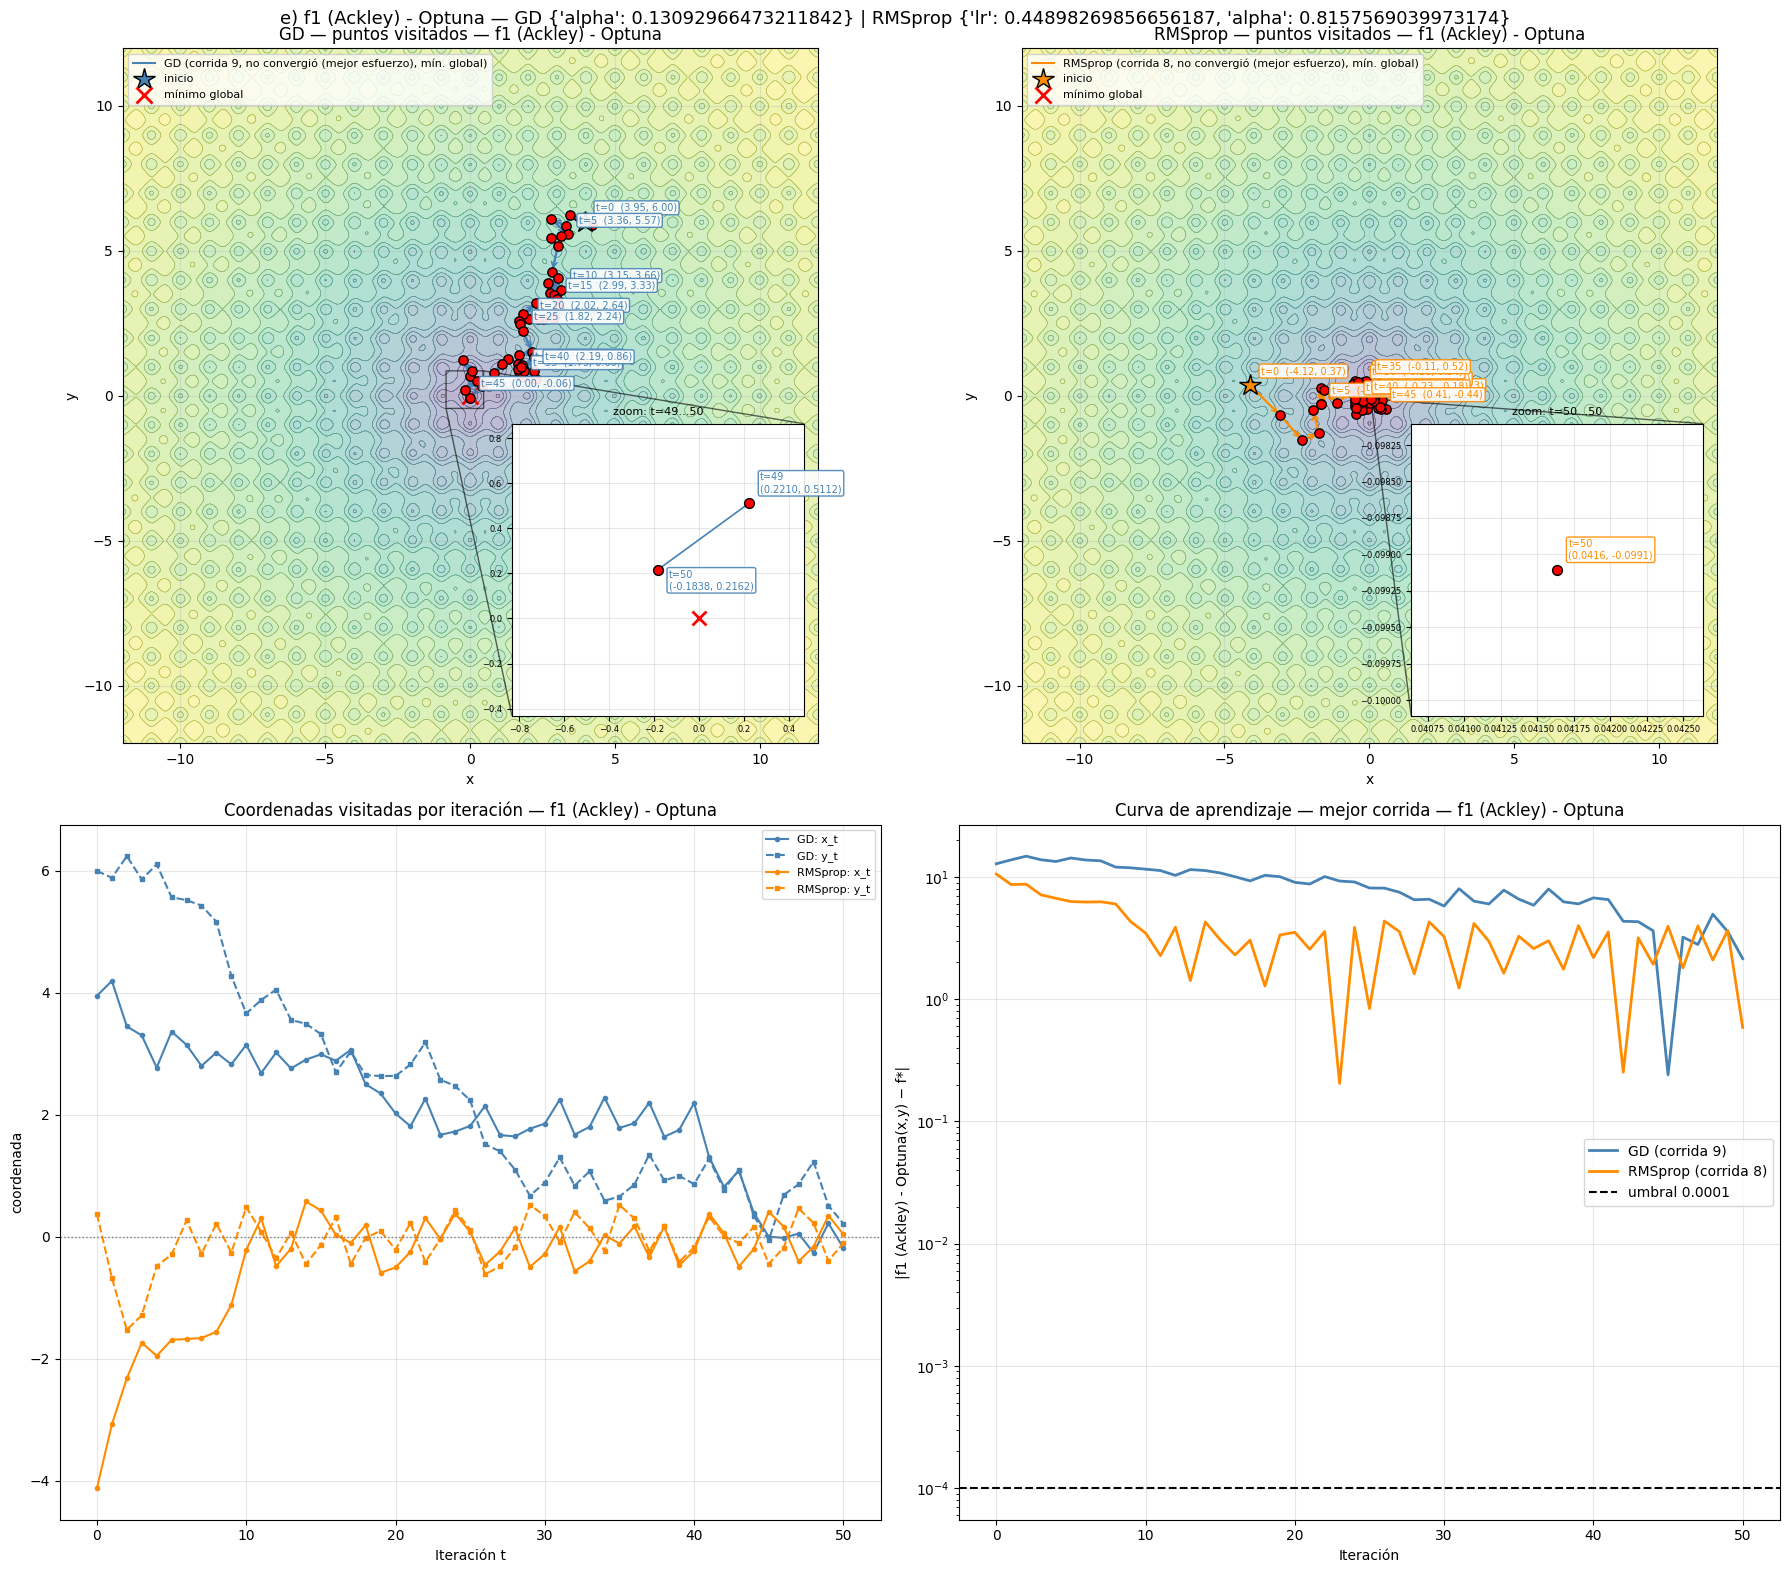

In [11]:
def f1(punto, eps=1e-12):
    """!
    @brief Función de Ackley, usada como benchmark de optimización no convexa.

    Tiene un único mínimo global en (0,0) con valor 0, rodeado de un plateau
    con múltiples mínimos locales generados por el término coseno.

    @param punto Tensor de 2 elementos (x, y) donde se evalúa la función.
    @param eps Constante pequeña para evitar problemas numéricos en la raíz cuadrada cerca del origen.
    @return Valor escalar de f1 en el punto dado.
    """
    n = punto.numel()
    termino_1 = -20 * torch.exp(-0.2 * torch.sqrt(torch.sum(punto ** 2) / n + eps))
    termino_2 = -torch.exp(torch.sum(torch.cos(2 * math.pi * punto)) / n)
    return termino_1 + termino_2 + math.e + 20


torch.manual_seed(0)
punto_inicial_f1 = torch.empty(2).uniform_(-10, 10)





def reportar_optuna(metodo, nombre_f, study, hp_manual, valor_manual):
    """!
    @brief Imprime en formato Markdown un reporte comparativo entre Optuna y la calibración manual, incluyendo un veredicto.

    A diferencia de otras versiones de esta función, aquí se calcula explícitamente
    la diferencia entre el valor manual y el de Optuna, y se imprime un veredicto
    textual indicando cuál de los dos métodos de calibración obtuvo mejor resultado.

    @param metodo Nombre del algoritmo ("GD" o "RMSprop").
    @param nombre_f Nombre de la función objetivo calibrada.
    @param study Objeto de estudio de Optuna ya optimizado, contiene los mejores hiperparámetros encontrados.
    @param hp_manual Diccionario con los hiperparámetros elegidos manualmente, para comparación.
    @param valor_manual Valor final de la función alcanzado con los hiperparámetros manuales.
    @return No devuelve nada; muestra el reporte directamente con display(Markdown(...)).
    """
    bp = study.best_params
    params_md = "  ·  ".join(f"{k} = {v:.5f}" for k, v in bp.items())
    manual_md = ", ".join(f"{k}={v}" for k, v in hp_manual.items())
    mejora = valor_manual - study.best_value
    veredicto = ("Optuna mejora al manual" if mejora > 0 else
                 "Optuna no supera al manual" if mejora < 0 else "Empate")

    display(Markdown(f"""
---
# 🔎 Optuna — {metodo} — {nombre_f}

## Hiperparámetros encontrados
# `{params_md}`

## Valor final de la función: `{study.best_value:.6e}`

| | Hiperparámetros | Valor final |
|---|---|---|
| **Optuna** ({len(study.trials)} trials, TPE, seed=0) | `{params_md}` | `{study.best_value:.6e}` |
| **Manual** (grid) | `{manual_md}` | `{valor_manual:.6e}` |

**{veredicto}** (diferencia = {mejora:+.3e})

---
"""))


# ============================================================
# a) CALIBRACIÓN MANUAL — RMSprop — f1 (Ackley)
# Recorre un grid de learning rates (lr) y factores de decaimiento
# (alpha), corriendo RMSprop 25 iteraciones sobre punto_inicial.
# Grafica todas las curvas y selecciona la combinación con menor
# valor final de la función como "mejor manual".
# ============================================================
print("Punto inicial usado para calibrar (f1):", punto_inicial.tolist())

lrs_rms_f1 = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]
alphas_rms_f1 = [0.9, 0.99]

resultados_rms_calib_f1 = {}
for lr in lrs_rms_f1:
    for alpha in alphas_rms_f1:
        _, _, curva = rmsprop(f1, punto_inicial, lr=lr, alpha=alpha, n_iter=25)  # f_historial ya es la curva
        resultados_rms_calib_f1[(lr, alpha)] = curva

plt.figure(figsize=(10, 6))
for (lr, alpha), curva in resultados_rms_calib_f1.items():
    plt.plot(curva, label=f"lr={lr}, alpha={alpha}")
plt.xlabel("Iteración"); plt.ylabel("f1(x,y)")
plt.title("a) Curvas de aprendizaje — Calibración manual RMSprop — f1 (Ackley)")
plt.legend(fontsize=8, ncol=2); plt.grid(True, alpha=0.3)
plt.show()

mejor_combo_rms_f1 = min(resultados_rms_calib_f1, key=lambda k: resultados_rms_calib_f1[k][-1])
mejor_lr_rms_f1, mejor_alpha_rms_f1 = mejor_combo_rms_f1
valor_manual_rms_f1 = resultados_rms_calib_f1[mejor_combo_rms_f1][-1]
reportar_mejor_manual("RMSprop", "f1", dict(lr=mejor_lr_rms_f1, alpha=mejor_alpha_rms_f1), valor_manual_rms_f1)


# --- Optuna RMS Prop---
def objetivo_rms_f1(trial):
    """!
    @brief Función objetivo de Optuna para calibrar RMSprop sobre f1 (Ackley).

    Corre RMSprop con los hiperparámetros propuestos por Optuna durante 25
    iteraciones y devuelve directamente el valor final de la función alcanzado
    (sin lógica de convergencia/penalización, a diferencia de la versión usada para f0).

    @param trial Objeto Trial de Optuna, usado para muestrear los hiperparámetros lr y alpha.
    @return Valor final de f1 alcanzado tras las 25 iteraciones; menor es mejor.
    """
    lr = trial.suggest_float("lr", 1e-4, 1.0, log=True)
    alpha = trial.suggest_float("alpha", 0.8, 0.999)
    _, _, curva = rmsprop(f1, punto_inicial, lr=lr, alpha=alpha, n_iter=25)
    return curva[-1]

study_rms_f1 = optuna.create_study(direction="minimize",
                                   sampler=optuna.samplers.TPESampler(seed=0))
study_rms_f1.optimize(objetivo_rms_f1, n_trials=50)

mejor_lr_rms_f1_optuna    = study_rms_f1.best_params["lr"]
mejor_alpha_rms_f1_optuna = study_rms_f1.best_params["alpha"]

reportar_optuna("RMSprop", "f1", study_rms_f1,
                hp_manual=dict(lr=mejor_lr_rms_f1, alpha=mejor_alpha_rms_f1),
                valor_manual=valor_manual_rms_f1)


# ============================================================
# b) CALIBRACIÓN MANUAL — Descenso de Gradiente — f1 (Ackley)
# Mismo procedimiento que el bloque anterior, pero para GD en vez
# de RMSprop: recorre un grid de alphas (learning rates).
# ============================================================
alphas_gd_f1 = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]

resultados_gd_calib_f1 = {}
for alpha in alphas_gd_f1:
    _, f_hist = correr_descenso_gradiente(f1, punto_inicial, alpha=alpha, n_iter=25)
    resultados_gd_calib_f1[alpha] = [v.item() for v in f_hist]

plt.figure(figsize=(10, 6))
for alpha, curva in resultados_gd_calib_f1.items():
    plt.plot(curva, label=f"alpha={alpha}")
plt.xlabel("Iteración"); plt.ylabel("f1(x,y)")
plt.title("b) Curvas de aprendizaje — Calibración manual GD — f1 (Ackley)")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.show()

mejor_alpha_gd_f1 = min(resultados_gd_calib_f1, key=lambda k: resultados_gd_calib_f1[k][-1])
valor_manual_gd_f1 = resultados_gd_calib_f1[mejor_alpha_gd_f1][-1]
reportar_mejor_manual("GD", "f1", dict(alpha=mejor_alpha_gd_f1), valor_manual_gd_f1)


# --- Optuna (solo reporte) ---
def objetivo_gd_f1(trial):
    """!
    @brief Función objetivo de Optuna para calibrar Descenso de Gradiente sobre f1 (Ackley).

    Corre GD con el alpha propuesto por Optuna durante 25 iteraciones y
    devuelve directamente el valor final de la función alcanzado.

    @param trial Objeto Trial de Optuna, usado para muestrear el hiperparámetro alpha.
    @return Valor final de f1 alcanzado tras las 25 iteraciones; menor es mejor.
    """
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    _, f_hist = correr_descenso_gradiente(f1, punto_inicial, alpha=alpha, n_iter=25)
    return f_hist[-1].item()

study_gd_f1 = optuna.create_study(direction="minimize",
                                  sampler=optuna.samplers.TPESampler(seed=0))
study_gd_f1.optimize(objetivo_gd_f1, n_trials=25)

mejor_alpha_gd_f1_optuna = study_gd_f1.best_params["alpha"]

reportar_optuna("GD", "f1", study_gd_f1,
                hp_manual=dict(alpha=mejor_alpha_gd_f1),
                valor_manual=valor_manual_gd_f1)


UMBRAL_F1 = 1e-4

def a_numpy(trayectoria):
    """!
    @brief Convierte una trayectoria de puntos (lista de tensores) a un arreglo NumPy.

    @param trayectoria Lista o tupla de tensores de PyTorch de forma (2,), o un único tensor de forma (T,2).
    @return Arreglo NumPy de forma (T,2) con la trayectoria completa.
    """
    if isinstance(trayectoria, (list, tuple)):
        trayectoria = torch.stack([p.detach() for p in trayectoria])
    return trayectoria.detach().cpu().numpy()


def corridas_10(nombre, ejecutar_una, funcion, optimos_globales=[(0.0, 0.0)], radio=0.5, umbral=UMBRAL_CONVERGENCIA):
    """!
    @brief Ejecuta un algoritmo de optimización sobre 10 puntos iniciales distintos y resume los resultados.

    Para cada punto inicial, corre el algoritmo, verifica si convergió por debajo
    del umbral, y clasifica el punto final como mínimo "global" o "local" según
    su distancia al óptimo conocido más cercano.

    @param nombre Nombre descriptivo del método (usado solo para el print de la tabla).
    @param ejecutar_una Función que recibe un punto inicial y devuelve la trayectoria completa.
    @param funcion Función objetivo usada para evaluar el valor de la función en cada punto de la trayectoria.
    @param optimos_globales Lista de puntos (tuplas) que representan los mínimos globales conocidos de la función.
    @param radio Distancia máxima a un óptimo para considerar la corrida como "global".
    @param umbral Valor por debajo del cual se considera que la corrida convergió.
    @return DataFrame de pandas con una fila por corrida: punto inicial, si convergió, iteración de convergencia, valor final y clasificación.
    """
    filas = []
    for i, p0 in enumerate(puntos_iniciales):
        trayectoria = ejecutar_una(p0)
        curva = [funcion(p).item() for p in trayectoria]
        convergio, it = iteracion_convergencia(curva, umbral=umbral)
        x_fin = trayectoria[-1]

        distancia_minima = min(
            torch.norm(x_fin - torch.tensor(opt)).item()
            for opt in optimos_globales
        )

        filas.append({
            "corrida": i + 1,
            "punto_inicial": [round(v, 3) for v in p0.tolist()],
            "convergio": convergio,
            "iteracion_convergencia": it if convergio else "No convergió",
            "valor_final": curva[-1],
            "minimo": "global" if distancia_minima < radio else "local",
        })
    tabla = pd.DataFrame(filas)
    print(f"=== d.1) Tabla {nombre} — 10 corridas ===")
    print(tabla.to_string(index=False), "\n")
    return tabla


# ============================================================
# d.1) 10 CORRIDAS usando los hiperparámetros de OPTUNA — f1 (Ackley)
# Ejecuta GD y RMSprop, cada uno con su alpha/lr encontrado por
# Optuna, sobre los 10 puntos iniciales, y arma las tablas de
# resultados correspondientes.
# ============================================================
tabla_gd_f1_optuna = corridas_10("Descenso de Gradiente (Optuna)",
    lambda p0: correr_descenso_gradiente(f1, p0, alpha=mejor_alpha_gd_f1_optuna, n_iter=N_ITER)[0],
    funcion=f1,
    optimos_globales=[(0.0, 0.0)])

tabla_rms_f1_optuna = corridas_10("RMSprop (Optuna)",
    lambda p0: rmsprop(f1, p0, lr=mejor_lr_rms_f1_optuna, alpha=mejor_alpha_rms_f1_optuna, n_iter=N_ITER)[1],
    funcion=f1,
    optimos_globales=[(0.0, 0.0)])

resumen_10_corridas(tabla_rms_f1_optuna, "RMSprop (Optuna) — f1")
resumen_10_corridas(tabla_gd_f1_optuna, "Descenso de Gradiente (Optuna) — f1")


# ============================================================
# e) Gráfica final — mejor corrida de cada método — f1 (Ackley), usando Optuna
# ============================================================
graficar_e_funcion(
    "f1 (Ackley) - Optuna", f1,
    tablas={"GD": tabla_gd_f1_optuna, "RMSprop": tabla_rms_f1_optuna},
    ejecutores={
        "GD":      lambda p0: correr_descenso_gradiente(f1, p0, alpha=mejor_alpha_gd_f1_optuna, n_iter=N_ITER)[0],
        "RMSprop": lambda p0: rmsprop(f1, p0, lr=mejor_lr_rms_f1_optuna, alpha=mejor_alpha_rms_f1_optuna, n_iter=N_ITER)[1],
    },
    hp={"GD": dict(alpha=mejor_alpha_gd_f1_optuna), "RMSprop": dict(lr=mejor_lr_rms_f1_optuna, alpha=mejor_alpha_rms_f1_optuna)},
    x_opt=(0.0, 0.0), f_opt=0.0,
    umbral=UMBRAL_F1, n_malla=400, niveles_log=False,
)

Punto inicial usado para calibrar (f1): [-0.07486820220947266, 5.364436149597168]


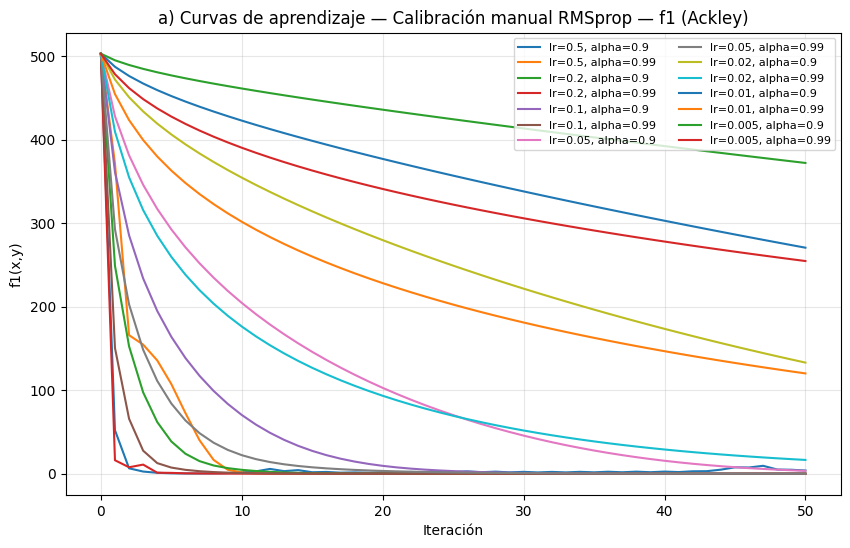

**Mejores valores (calibración manual) — RMSprop — f2:** `lr=0.5, alpha=0.99`  
Iteraciones hasta el umbral: `0` · Valor final: `2.300000e+01`


---
# 🔎 Optuna — RMSprop — f2

## Hiperparámetros encontrados
# `lr = 0.80900  ·  alpha = 0.98122`

## Valor final de la función: `0.000000e+00`

| | Hiperparámetros | Valor final |
|---|---|---|
| **Optuna** (50 trials, TPE, seed=0) | `lr = 0.80900  ·  alpha = 0.98122` | `0.000000e+00` |
| **Manual** (grid) | `lr=0.5, alpha=0.99` | `9.094947e-13` |

**Optuna mejora al manual** (diferencia = +9.095e-13)

---


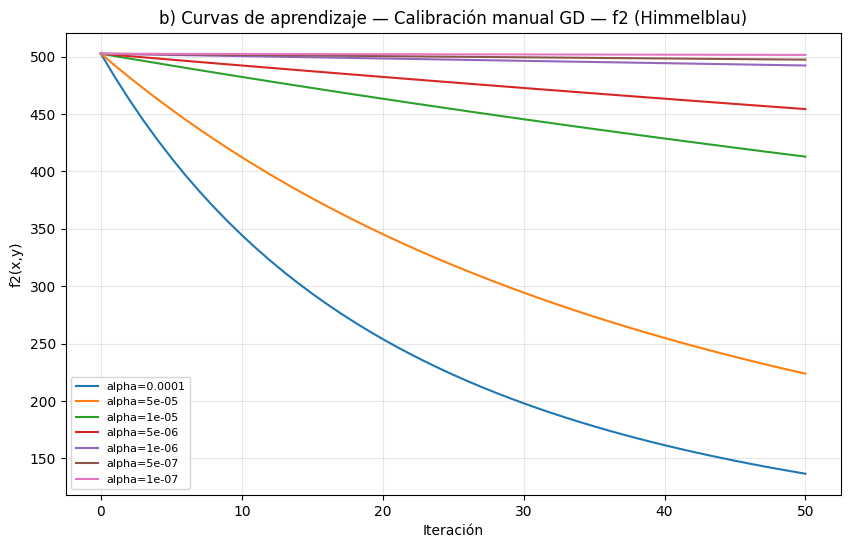

**Mejores valores (calibración manual) — GD — f2:** `alpha=0.0001`  
Iteraciones hasta el umbral: `136` · Valor final: `inf`

[W 2026-09-24 23:28:09,972] Trial 1 failed with parameters: {'alpha': 0.07257005721594278} because of the following error: The value nan is not acceptable.
[W 2026-09-24 23:28:09,973] Trial 1 failed with value nan.
[W 2026-09-24 23:28:10,004] Trial 2 failed with parameters: {'alpha': 0.02576638574613589} because of the following error: The value nan is not acceptable.
[W 2026-09-24 23:28:10,005] Trial 2 failed with value nan.
[W 2026-09-24 23:28:10,088] Trial 5 failed with parameters: {'alpha': 0.03833332156156663} because of the following error: The value nan is not acceptable.
[W 2026-09-24 23:28:10,089] Trial 5 failed with value nan.
[W 2026-09-24 23:28:10,161] Trial 7 failed with parameters: {'alpha': 0.36905577292137587} because of the following error: The value nan is not acceptable.
[W 2026-09-24 23:28:10,162] Trial 7 failed with value nan.
[W 2026-09-24 23:28:10,208] Trial 8 failed with parameters: {'alpha': 0.7155682161754863} because of the following error: The value nan is n


---
# 🔎 Optuna — GD — f2

## Hiperparámetros encontrados
# `alpha = 0.00563`

## Valor final de la función: `2.273737e-13`

| | Hiperparámetros | Valor final |
|---|---|---|
| **Optuna** (50 trials, TPE, seed=0) | `alpha = 0.00563` | `2.273737e-13` |
| **Manual** (grid) | `alpha=0.0001` | `1.365005e+02` |

**Optuna mejora al manual** (diferencia = +1.365e+02)

---


=== d.1) Tabla Descenso de Gradiente (Optuna) — 10 corridas ===
 corrida    punto_inicial  convergio  iteracion_convergencia  valor_final minimo
       1  [-0.075, 5.364]       True                      28    2.274e-13 global
       2  [-8.23, -7.359]       True                      41    3.345e-06 global
       3  [-3.852, 2.682]       True                      13    9.095e-13 global
       4  [-0.198, 7.929]       True                      23    0.000e+00 global
       5  [-0.887, 2.646]       True                      22    2.274e-13 global
       6 [-3.022, -1.966]       True                      16    0.000e+00 global
       7 [-9.553, -6.623]       True                      32    1.367e-07 global
       8   [-4.122, 0.37]       True                      23    2.274e-13 global
       9     [3.953, 6.0]       True                      36    1.164e-06 global
      10 [-6.779, -4.355]       True                      15    0.000e+00 global 

=== d.1) Tabla RMSprop (Optuna) — 10 corrid

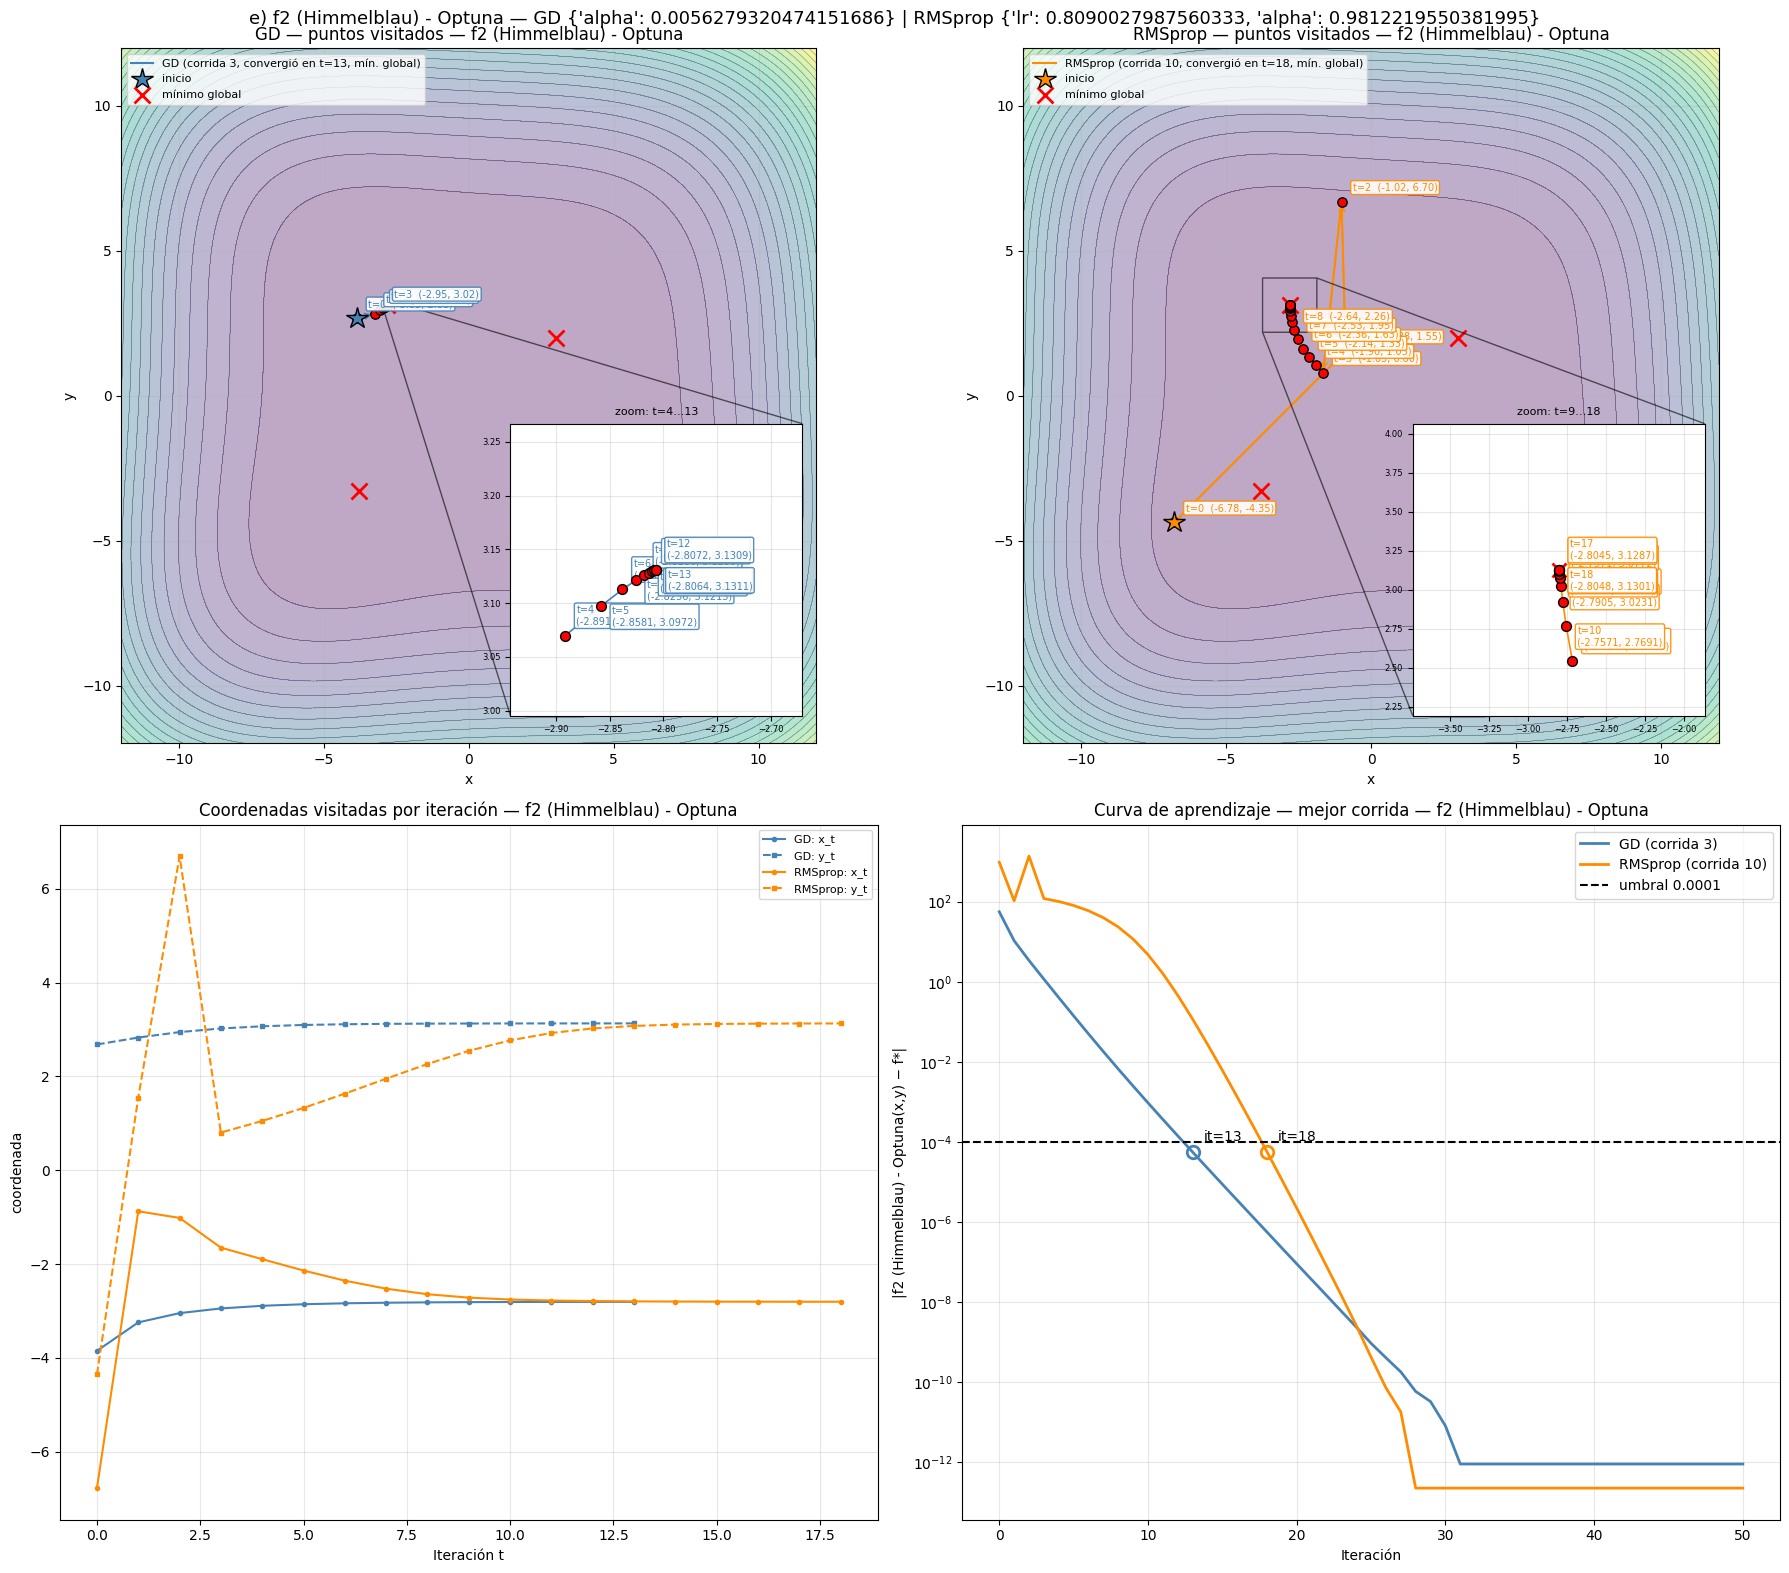

In [12]:
def f2(punto):
    """!
    @brief Función de Himmelblau, usada como benchmark de optimización con múltiples mínimos globales.

    Tiene 4 mínimos globales, todos con valor 0, ubicados en:
    (3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283) y (3.584, -1.848).

    @param punto Tensor de 2 elementos (x, y) donde se evalúa la función.
    @return Valor escalar de f2 en el punto dado.
    """
    termino1 = (punto[0] ** 2 + punto[1] - 11) ** 2
    termino2 = (punto[0] + punto[1] ** 2 - 7) ** 2
    return termino1 + termino2


torch.manual_seed(0)
punto_inicial = torch.empty(2).uniform_(-10, 10)

from torch.autograd.functional import hessian


# ============================================================
# a) CALIBRACIÓN MANUAL — RMSprop — f2 (Himmelblau)
# Recorre un grid de learning rates (lr) y factores de decaimiento
# (alpha), corriendo RMSprop sobre punto_inicial. Grafica las
# curvas y selecciona la mejor combinación según puntuar()
# (prioriza convergencia temprana, penaliza NaN/inf).
# ============================================================
print("Punto inicial usado para calibrar (f1):", punto_inicial.tolist())

lrs_rms_f2 = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]
alphas_rms_f2 = [0.9, 0.99]

resultados_rms_calib_f2 = {}
for lr in lrs_rms_f2:
    for alpha in alphas_rms_f2:
        _, _, curva = rmsprop(f2, punto_inicial, lr=lr, alpha=alpha, n_iter=N_ITER)  # f_historial ya es la curva
        resultados_rms_calib_f2[(lr, alpha)] = curva

plt.figure(figsize=(10, 6))
for (lr, alpha), curva in resultados_rms_calib_f2.items():
    plt.plot(curva, label=f"lr={lr}, alpha={alpha}")
plt.xlabel("Iteración"); plt.ylabel("f1(x,y)")
plt.title("a) Curvas de aprendizaje — Calibración manual RMSprop — f1 (Ackley)")
plt.legend(fontsize=8, ncol=2); plt.grid(True, alpha=0.3)
plt.show()

mejor_combo_rms_f2 = min(resultados_rms_calib_f2, key=lambda k: puntuar(resultados_rms_calib_f2[k]))
mejor_lr_rms_f2, mejor_alpha_rms_f2 = mejor_combo_rms_f2
it_mejor_rms_f2 = puntuar(resultados_rms_calib_f2[mejor_combo_rms_f2])[0]
valor_manual_rms_f2 = resultados_rms_calib_f2[mejor_combo_rms_f2][-1]
reportar_mejor_manual("RMSprop", "f2",
                      dict(lr=mejor_lr_rms_f2, alpha=mejor_alpha_rms_f2),
                      it_mejor_rms_f2, valor_manual_rms_f2)


def objetivo_rms_f2(trial):
    """!
    @brief Función objetivo de Optuna para calibrar RMSprop sobre f2 (Himmelblau).

    Corre RMSprop con los hiperparámetros propuestos por Optuna y devuelve
    directamente el valor final de la función alcanzado.

    @param trial Objeto Trial de Optuna, usado para muestrear los hiperparámetros lr y alpha.
    @return Valor final de f2 alcanzado tras N_ITER iteraciones; menor es mejor.
    """
    lr = trial.suggest_float("lr", 1e-4, 1.0, log=True)
    alpha = trial.suggest_float("alpha", 0.8, 0.999)
    _, _, curva = rmsprop(f2, punto_inicial, lr=lr, alpha=alpha, n_iter=N_ITER)
    return curva[-1]

study_rms_f2 = optuna.create_study(direction="minimize",
                                   sampler=optuna.samplers.TPESampler(seed=0))
study_rms_f2.optimize(objetivo_rms_f2, n_trials=50)

mejor_lr_rms_f2_optuna    = study_rms_f2.best_params["lr"]
mejor_alpha_rms_f2_optuna = study_rms_f2.best_params["alpha"]

reportar_optuna("RMSprop", "f2", study_rms_f2,
                hp_manual=dict(lr=mejor_lr_rms_f2, alpha=mejor_alpha_rms_f2),
                valor_manual=valor_manual_rms_f2)


# ============================================================
# b) CALIBRACIÓN MANUAL — Descenso de Gradiente — f2 (Himmelblau)
# Nota: el grid de alphas aquí es mucho más pequeño (1e-4 a 1e-7)
# que en f0/f1, porque los gradientes de Himmelblau crecen de forma
# cúbica lejos del origen y valores de alpha más grandes producen
# divergencia numérica (NaN) con puntos iniciales lejanos.
# ============================================================
alphas_gd_f2 = [1e-4, 5e-5, 1e-5, 5e-6, 1e-6, 5e-7, 1e-7]

resultados_gd_calib_f2 = {}
for alpha in alphas_gd_f2:
    _, f_hist = correr_descenso_gradiente(f2, punto_inicial, alpha=alpha, n_iter=N_ITER)
    resultados_gd_calib_f2[alpha] = [v.item() for v in f_hist]

plt.figure(figsize=(10, 6))
for alpha, curva in resultados_gd_calib_f2.items():
    plt.plot(curva, label=f"alpha={alpha}")
plt.xlabel("Iteración"); plt.ylabel("f2(x,y)")
plt.title("b) Curvas de aprendizaje — Calibración manual GD — f2 (Himmelblau)")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.show()

mejor_alpha_gd_f2 = min(resultados_gd_calib_f2, key=lambda k: puntuar(resultados_gd_calib_f2[k]))
it_mejor_gd_f2 = puntuar(resultados_gd_calib_f2[mejor_alpha_gd_f2])[0]
valor_manual_gd_f2 = resultados_gd_calib_f2[mejor_alpha_gd_f2][-1]
reportar_mejor_manual("GD", "f2",
                      dict(alpha=mejor_alpha_gd_f2),
                      it_mejor_gd_f2, valor_manual_gd_f2)


# --- Optuna (solo reporte) ---
def objetivo_gd_f2(trial):
    """!
    @brief Función objetivo de Optuna para calibrar Descenso de Gradiente sobre f2 (Himmelblau).

    Corre GD con el alpha propuesto por Optuna y devuelve directamente el
    valor final de la función alcanzado (sin recorte de gradiente / clipping).

    @param trial Objeto Trial de Optuna, usado para muestrear el hiperparámetro alpha.
    @return Valor final de f2 alcanzado tras N_ITER iteraciones; menor es mejor.
    """
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    _, f_hist = correr_descenso_gradiente(f2, punto_inicial, alpha=alpha, n_iter=N_ITER)
    return f_hist[-1].item()

study_gd_f2 = optuna.create_study(direction="minimize",
                                  sampler=optuna.samplers.TPESampler(seed=0))
study_gd_f2.optimize(objetivo_gd_f2, n_trials=50)

mejor_alpha_gd_f2_optuna = study_gd_f2.best_params["alpha"]

reportar_optuna("GD", "f2", study_gd_f2,
                hp_manual=dict(alpha=mejor_alpha_gd_f2),
                valor_manual=valor_manual_gd_f2)


# ============================================================
# d.1) 10 CORRIDAS usando los hiperparámetros de OPTUNA — f2 (Himmelblau)
# A diferencia de f0/f1 (un único mínimo global), aquí se pasan los
# 4 mínimos globales conocidos de Himmelblau en optimos_globales,
# para que corridas_10 clasifique correctamente cada corrida como
# "global" si terminó cerca de CUALQUIERA de los 4, no solo de (0,0).
# ============================================================
tabla_gd_f2_optuna = corridas_10("Descenso de Gradiente (Optuna)",
    lambda p0: correr_descenso_gradiente(f2, p0, alpha=mejor_alpha_gd_f2_optuna, n_iter=N_ITER)[0],
    funcion=f2,
    optimos_globales=[(3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)])

tabla_rms_f2_optuna = corridas_10("RMSprop (Optuna)",
    lambda p0: rmsprop(f2, p0, lr=mejor_lr_rms_f2_optuna, alpha=mejor_alpha_rms_f2_optuna, n_iter=N_ITER)[1],
    funcion=f2,
    optimos_globales=[(3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)])

resumen_10_corridas(tabla_rms_f2_optuna, "RMSprop (Optuna) — f2")
resumen_10_corridas(tabla_gd_f2_optuna, "Descenso de Gradiente (Optuna) — f2")


# ============================================================
# e) Gráfica final — mejor corrida de cada método — f2 (Himmelblau), usando Optuna
# Se pasa la lista de los 4 mínimos globales en x_opt, para que
# dibujar_panel marque los 4 en el gráfico y calcule la distancia
# de la trayectoria final contra el más cercano de ellos.
# ============================================================
graficar_e_funcion(
    "f2 (Himmelblau) - Optuna", f2,
    tablas={"GD": tabla_gd_f2_optuna, "RMSprop": tabla_rms_f2_optuna},
    ejecutores={
        "GD":      lambda p0: correr_descenso_gradiente(f2, p0, alpha=mejor_alpha_gd_f2_optuna, n_iter=N_ITER)[0],
        "RMSprop": lambda p0: rmsprop(f2, p0, lr=mejor_lr_rms_f2_optuna, alpha=mejor_alpha_rms_f2_optuna, n_iter=N_ITER)[1],
    },
    hp={"GD": dict(alpha=mejor_alpha_gd_f2_optuna), "RMSprop": dict(lr=mejor_lr_rms_f2_optuna, alpha=mejor_alpha_rms_f2_optuna)},
    x_opt=[(3.0, 2.0), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)],
    f_opt=0.0,
    umbral=UMBRAL_F1, n_malla=400, niveles_log=False,
)